# Learning Curve Analysis: Experiment 2

**Objective**: Analyze how method performance degrades as the number of training rows decreases.

---

## Overview

**Experiment 2** evaluates performance degradation across varying training set sizes:
1. Tests methods at multiple row limits (e.g., 15k, 14.9k, ..., 100 rows)
2. Uses **NO HPO** (default parameters only) to isolate the effect of data size
3. All metrics are **averaged across CV folds** per dataset-method-row_limit combination

This notebook is structured as follows (for both PD and LGD):
- **Part 1: General Statistics & Averaged Graphs** - Degradation stats, smoothed trend lines, Foundation vs Baselines comparison
- **Part 2: Rank Analysis** - Rank evolution, Spearman rank correlation, Pearson performance correlation
- **Part 3: Per-Dataset Analysis** - Individual dataset learning curves

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle

# =============================================================================
# SETUP PATHS (Notebook is in notebooks/ folder)
# =============================================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

# Import foundation methods list from method config
from src.methods.method_config import FOUNDATION_METHODS

EXPERIMENT_NAME = "experiment2"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "figures" / "experiment2"
(FIGURES_DIR / "pd").mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "lgd").mkdir(parents=True, exist_ok=True)

# Load config to get expected row limits
from src.utils.config_reader import load_config

print("=" * 80)
print("  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS")
print("=" * 80)
print(f"Project root:       {PROJECT_ROOT}")
print(f"Results directory:  {RESULTS_DIR}")
print(f"Summary directory:  {SUMMARY_DIR}")
print(f"Figures directory:  {FIGURES_DIR}")

# =============================================================================
# LOAD CONFIG AND CHECK COMPLETENESS
# =============================================================================

try:
    config = load_config("Experiment2")
    lc_config = config.get("learning_curve", {})
    row_max = lc_config.get("row_max", 15000)
    row_min = lc_config.get("row_min", 500)
    row_step = lc_config.get("row_step", 100)
    
    # Generate expected row limits
    expected_row_limits = []
    current = row_max
    while current >= row_min:
        expected_row_limits.append(current)
        current -= row_step
    if expected_row_limits[-1] != row_min:
        expected_row_limits.append(row_min)
    
    print(f"\nExpected row limits from config: {expected_row_limits}")
    print(f"  row_max={row_max}, row_min={row_min}, row_step={row_step}")
    
    # Get expected datasets and methods
    pd_datasets = list(config.get("datasets", {}).get("pd", {}).keys())
    lgd_datasets = list(config.get("datasets", {}).get("lgd", {}).keys())
    pd_methods = list(config.get("methods", {}).get("pd", {}).keys())
    lgd_methods = list(config.get("methods", {}).get("lgd", {}).keys())
    
    print(f"\nExpected PD datasets: {len(pd_datasets)}")
    print(f"Expected PD methods: {len(pd_methods)}")
    print(f"Expected LGD datasets: {len(lgd_datasets)}")
    print(f"Expected LGD methods: {len(lgd_methods)}")
    
except Exception as e:
    print(f"\n[WARNING] Could not load config: {e}")
    expected_row_limits = None
    pd_datasets, lgd_datasets = [], []
    pd_methods, lgd_methods = [], []

# =============================================================================
# CHECK RESULT COMPLETENESS
# =============================================================================
# 
# Result file structure for Experiment2:
#   - Results stored as: {results_dir}/{task_type}/{dataset}.pkl
#   - Each .pkl contains: results[row_limit][method] = fold_results
#   - This mirrors Experiment1's structure with row_limit replacing hpo_mode
#
# =============================================================================

def check_result_completeness(results_dir: Path, task_type: str, expected_datasets: list, 
                               expected_methods: list, expected_row_limits: list):
    """
    Check which dataset-method-row_limit combinations are missing results.
    
    Reads each {dataset}.pkl file and checks the nested structure:
        results[row_limit][method] = fold_results
    
    Returns:
        missing_results: dict mapping "dataset|method" -> list of missing row_limits
        complete_count: number of complete dataset-method-row_limit combinations
        total_expected: total number of expected combinations
    """
    results_subdir = results_dir / task_type
    
    if not results_subdir.exists():
        print(f"[WARNING] Results directory not found: {results_subdir}")
        return {}, 0, len(expected_datasets) * len(expected_methods) * len(expected_row_limits)
    
    missing_results = {}
    complete_count = 0
    total_expected = len(expected_datasets) * len(expected_methods) * len(expected_row_limits)
    
    for dataset in expected_datasets:
        # Result file is {dataset}.pkl (NOT {dataset}_{method}_row{limit}.pkl)
        result_file = results_subdir / f"{dataset}.pkl"
        
        # Load existing results for this dataset
        dataset_results = {}
        if result_file.exists():
            try:
                with open(result_file, 'rb') as f:
                    dataset_results = pickle.load(f)
            except Exception as e:
                print(f"[WARNING] Could not load {result_file.name}: {e}")
        
        # Check each method
        for method in expected_methods:
            missing_row_limits = []
            
            for row_limit in expected_row_limits:
                # Check if results[row_limit][method] exists
                if row_limit in dataset_results and method in dataset_results.get(row_limit, {}):
                    complete_count += 1
                else:
                    missing_row_limits.append(row_limit)
            
            if missing_row_limits:
                key = f"{dataset}|{method}"
                missing_results[key] = missing_row_limits
    
    return missing_results, complete_count, total_expected


print("\n" + "=" * 80)
print("  RESULT COMPLETENESS CHECK")
print("=" * 80)

if expected_row_limits and pd_datasets and pd_methods:
    pd_missing, pd_complete, pd_total = check_result_completeness(
        RESULTS_DIR, "pd", pd_datasets, pd_methods, expected_row_limits
    )
    
    pct_complete = 100*pd_complete/pd_total if pd_total > 0 else 0
    print(f"\nPD Task Completeness: {pd_complete}/{pd_total} ({pct_complete:.1f}%)")
    
    if pd_missing:
        print(f"\n[MISSING PD RESULTS] {len(pd_missing)} dataset-method combinations incomplete:")
        # Modified to show ALL results instead of just the first 20
        for key, missing_limits in sorted(pd_missing.items()): 
            dataset, method = key.split("|")
            print(f"  {dataset} | {method}: missing row_limits = {missing_limits}")
    else:
        print("  All PD results complete!")

if expected_row_limits and lgd_datasets and lgd_methods:
    lgd_missing, lgd_complete, lgd_total = check_result_completeness(
        RESULTS_DIR, "lgd", lgd_datasets, lgd_methods, expected_row_limits
    )
    
    pct_complete = 100*lgd_complete/lgd_total if lgd_total > 0 else 0
    print(f"\nLGD Task Completeness: {lgd_complete}/{lgd_total} ({pct_complete:.1f}%)")
    
    if lgd_missing:
        print(f"\n[MISSING LGD RESULTS] {len(lgd_missing)} dataset-method combinations incomplete:")
        # Modified to show ALL results instead of just the first 20
        for key, missing_limits in sorted(lgd_missing.items()):
            dataset, method = key.split("|")
            print(f"  {dataset} | {method}: missing row_limits = {missing_limits}")
    else:
        print("  All LGD results complete!")

# =============================================================================
# GENERATE SUMMARIES IF NOT ALREADY PRESENT
# =============================================================================

# Check if summary folder exists and has files
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print(f"\n Summary files already exist. Skipping generation.")
    print(f"   (Delete {SUMMARY_DIR} manually to regenerate)")
else:
    print(f"\n Summary files not found. Generating summaries...")
    
    # Import and run summarize_results
    from src.utils.summarize_results import summarize_results
    
    print("\n" + "=" * 80)
    summarize_results(experiment=EXPERIMENT_NAME)
    print("=" * 80)

# Ensure figures directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("\n Setup complete! Ready for analysis.")
print("=" * 80)

  EXPERIMENT 2 POST-ANALYSIS: LEARNING CURVE ANALYSIS
Project root:       c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Results directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2
Summary directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment2\summary
Figures directory:  c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment2

Expected row limits from config: [15000, 14900, 14800, 14700, 14600, 14500, 14400, 14300, 14200, 14100, 14000, 13900, 13800, 13700, 13600, 13500, 13400, 13300, 13200, 13100, 13000, 12900, 12800, 12700, 12600, 12500, 12400, 12300, 12200, 12100, 12000, 11900, 11800, 11700, 11600, 11500, 11400, 11300, 11200, 11100, 11000, 10900, 10800, 10700, 10600, 10500, 10400, 10300, 10200, 10100, 10000, 9900, 9800, 9700, 9600, 9500, 9400, 9300, 9200, 9100, 9000, 8900, 8800, 8700, 8600, 8500, 8400, 8300, 8200, 8100, 8000, 7900, 7800, 7700, 7600, 7500, 

In [2]:
# =============================================================================
# VISUALIZATION ROW LIMIT RANGE
# =============================================================================
# Only show results for row limits within this range.
# Set to None to use the full range available in the data.
VIS_ROW_MIN = 500    # Minimum row limit to include in visualizations/calculations
VIS_ROW_MAX = None   # Maximum row limit to include (None = no upper bound)

# =============================================================================
# FONT SCALE CONFIGURATION
# =============================================================================
# Single configurable constant controlling all font sizes in the notebook.
# Adjust this value to scale ALL text sizes proportionally.
# Default: 1.0 (suitable for notebook viewing). Increase for paper figures.
FONT_SCALE = 1.3

# Plotting configuration (all sizes relative to FONT_SCALE)
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = FONT_SCALE * 11
plt.rcParams['axes.titlesize'] = FONT_SCALE * 14
plt.rcParams['axes.labelsize'] = FONT_SCALE * 12
plt.rcParams['xtick.labelsize'] = FONT_SCALE * 9
plt.rcParams['ytick.labelsize'] = FONT_SCALE * 10
sns.set_style('whitegrid')

# Derived font sizes (use these in plotting functions)
FS_TITLE = FONT_SCALE * 16       # Main plot titles
FS_SUBTITLE = FONT_SCALE * 14    # Subplot titles / secondary titles
FS_AXIS_LABEL = FONT_SCALE * 12  # Axis labels (xlabel, ylabel)
FS_TICK = FONT_SCALE * 9         # Tick labels
FS_TICK_Y = FONT_SCALE * 10      # Y-axis tick labels
FS_ANNOT = FONT_SCALE * 7        # Heatmap annotation text
FS_LEGEND = FONT_SCALE * 10      # Legend text
FS_BAR_LABEL = FONT_SCALE * 9    # Labels on bar charts
FS_SUPTITLE = FONT_SCALE * 16    # Figure suptitles

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'
CMAP_DEGRADATION = 'RdYlGn_r'
CMAP_TIME = 'YlOrRd'

# Use a distinct color palette for learning curves
N_COLORS = 20
LEARNING_CURVE_PALETTE = sns.color_palette('husl', n_colors=N_COLORS)

# Global plot styling
MARKER_SIZE = 2
LINE_WIDTH = 1.0
LINE_WIDTH_THICK = 1.5
SAVE_DPI = 600

## 2. Data Loading

In [3]:
# Load raw and aggregated results
try:
    pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
    pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
    has_pd = True
except FileNotFoundError:
    print("Warning: PD results not found")
    pd_raw = pd.DataFrame()
    pd_agg = pd.DataFrame()
    has_pd = False

try:
    lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
    lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")
    has_lgd = True
except FileNotFoundError:
    print("Warning: LGD results not found")
    lgd_raw = pd.DataFrame()
    lgd_agg = pd.DataFrame()
    has_lgd = False

print("\n Data Overview:")

if has_pd and not pd_raw.empty:
    row_limits_pd = sorted(pd_raw['row_limit'].unique(), reverse=True)
    print(f"\nPD (Probability of Default):")
    print(f"  - Raw results: {len(pd_raw)} fold results")
    print(f"  - Methods: {pd_raw['method'].nunique()}")
    print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_pd)} ({max(row_limits_pd):,} -> {min(row_limits_pd):,})")
    print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

if has_lgd and not lgd_raw.empty:
    row_limits_lgd = sorted(lgd_raw['row_limit'].unique(), reverse=True)
    print(f"\nLGD (Loss Given Default):")
    print(f"  - Raw results: {len(lgd_raw)} fold results")
    print(f"  - Methods: {lgd_raw['method'].nunique()}")
    print(f"  - Datasets: {lgd_raw['dataset'].nunique()}")
    print(f"  - Row limits: {len(row_limits_lgd)} ({max(row_limits_lgd):,} -> {min(row_limits_lgd):,})")
    print(f"  - Methods: {sorted(lgd_raw['method'].unique())}")

# =============================================================================
# FILTER DATA TO VISUALIZATION RANGE
# =============================================================================
def filter_row_limits(df, row_min=None, row_max=None):
    """Filter dataframe to only include rows within the specified row_limit range."""
    if df.empty or 'row_limit' not in df.columns:
        return df
    filtered = df.copy()
    if row_min is not None:
        filtered = filtered[filtered['row_limit'] >= row_min]
    if row_max is not None:
        filtered = filtered[filtered['row_limit'] <= row_max]
    return filtered

if has_pd:
    pd_raw = filter_row_limits(pd_raw, VIS_ROW_MIN, VIS_ROW_MAX)
    pd_agg = filter_row_limits(pd_agg, VIS_ROW_MIN, VIS_ROW_MAX)
    if not pd_raw.empty:
        row_limits_pd = sorted(pd_raw['row_limit'].unique(), reverse=True)
        print(f"\n[Filtered] PD row limits: {len(row_limits_pd)} ({max(row_limits_pd):,} -> {min(row_limits_pd):,})")

if has_lgd:
    lgd_raw = filter_row_limits(lgd_raw, VIS_ROW_MIN, VIS_ROW_MAX)
    lgd_agg = filter_row_limits(lgd_agg, VIS_ROW_MIN, VIS_ROW_MAX)
    if not lgd_raw.empty:
        row_limits_lgd = sorted(lgd_raw['row_limit'].unique(), reverse=True)
        print(f"[Filtered] LGD row limits: {len(row_limits_lgd)} ({max(row_limits_lgd):,} -> {min(row_limits_lgd):,})")


 Data Overview:

PD (Probability of Default):
  - Raw results: 60000 fold results
  - Methods: 10
  - Datasets: 8
  - Row limits: 150 (15,000 -> 100)
  - Methods: ['LogReg', 'catboost', 'ftt', 'lightgbm', 'mitra', 'tabicl', 'tabpfn', 'tabpfn_real', 'tabpfn_v2', 'xgboost']

LGD (Loss Given Default):
  - Raw results: 10490 fold results
  - Methods: 7
  - Datasets: 2
  - Row limits: 150 (15,000 -> 100)
  - Methods: ['LinearRegression', 'autoint', 'catboost', 'lightgbm', 'modernNCA', 'tabpfn_v2', 'xgboost']

[Filtered] PD row limits: 146 (15,000 -> 500)
[Filtered] LGD row limits: 146 (15,000 -> 500)


In [4]:
# Display sample of raw data
if has_pd and not pd_raw.empty:
    print("\nSample PD Raw Data (first 10 rows):")
    display(pd_raw.head(10))
    
    print("\nPD Aggregated Data columns:")
    print(pd_agg.columns.tolist())


Sample PD Raw Data (first 10 rows):


,method,dataset,task,hpo_mode,fold_id,Optimal_Threshold,AUC,Gini,Avg_Precision,KS,...,F1,Precision,Recall,MCC,train_time,n_clipped_below,n_clipped_above,n_num_features,n_cat_features,row_limit
0,LogReg,0001.gmsc,pd,NO_HPO,1,0.168384,0.849600,0.699200,0.337360,0.549286,...,0.415350,0.378601,0.460000,0.371257,0.007509,0.0,0.0,10,0,15000
1,LogReg,0001.gmsc,pd,NO_HPO,2,0.158485,0.827664,0.655329,0.371278,0.519286,...,0.443914,0.424658,0.465000,0.402736,0.006930,0.0,0.0,10,0,15000
2,LogReg,0001.gmsc,pd,NO_HPO,3,0.158485,0.813997,0.627994,0.291140,0.504727,...,0.372506,0.336000,0.417910,0.324398,0.006843,0.0,0.0,10,0,15000
3,LogReg,0001.gmsc,pd,NO_HPO,4,0.168384,0.838224,0.676448,0.354933,0.516437,...,0.405594,0.381579,0.432836,0.360846,0.007040,0.0,0.0,10,0,15000
4,LogReg,0001.gmsc,pd,NO_HPO,5,0.138687,0.833119,0.666238,0.380271,0.502584,...,0.398422,0.330065,0.502488,0.354607,0.007245,0.0,0.0,10,0,15000
5,catboost,0001.gmsc,pd,NO_HPO,1,0.198081,0.860254,0.720507,0.379073,0.574643,...,0.421286,0.378486,0.475000,0.377729,20.517545,0.0,0.0,10,0,15000
6,catboost,0001.gmsc,pd,NO_HPO,2,0.148586,0.840964,0.681929,0.390987,0.551429,...,0.427966,0.371324,0.505000,0.385656,19.546516,0.0,0.0,10,0,15000
7,catboost,0001.gmsc,pd,NO_HPO,3,0.257475,0.831377,0.662754,0.333938,0.528318,...,0.413098,0.418367,0.407960,0.371554,20.993064,0.0,0.0,10,0,15000
8,catboost,0001.gmsc,pd,NO_HPO,4,0.188182,0.870617,0.741233,0.406328,0.609973,...,0.443418,0.413793,0.477612,0.401563,18.615402,0.0,0.0,10,0,15000
9,catboost,0001.gmsc,pd,NO_HPO,5,0.217879,0.844943,0.689886,0.391046,0.534754,...,0.416465,0.405660,0.427861,0.373515,21.496684,0.0,0.0,10,0,15000



PD Aggregated Data columns:
['method', 'dataset', 'row_limit', 'task', 'n_folds', 'AUC_mean', 'AUC_std', 'AUC_min', 'AUC_max', 'Accuracy_mean', 'Accuracy_std', 'Accuracy_min', 'Accuracy_max', 'Avg_Precision_mean', 'Avg_Precision_std', 'Avg_Precision_min', 'Avg_Precision_max', 'Balanced_Accuracy_mean', 'Balanced_Accuracy_std', 'Balanced_Accuracy_min', 'Balanced_Accuracy_max', 'Brier_mean', 'Brier_std', 'Brier_min', 'Brier_max', 'F1_mean', 'F1_std', 'F1_min', 'F1_max', 'Gini_mean', 'Gini_std', 'Gini_min', 'Gini_max', 'KS_mean', 'KS_std', 'KS_min', 'KS_max', 'LogLoss_mean', 'LogLoss_std', 'LogLoss_min', 'LogLoss_max', 'MCC_mean', 'MCC_std', 'MCC_min', 'MCC_max', 'Precision_mean', 'Precision_std', 'Precision_min', 'Precision_max', 'Recall_mean', 'Recall_std', 'Recall_min', 'Recall_max', 'row_limit_mean', 'row_limit_std', 'row_limit_min', 'row_limit_max', 'train_time_mean', 'train_time_std', 'train_time_min', 'train_time_max', 'n_clipped_below_mean', 'n_clipped_below_std', 'n_clipped_below

## 3. Helper Functions

In [5]:
def plot_learning_curves(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    dataset: str = None,
    figsize: tuple = (14, 8),
    show_std: bool = False,
    averaged: bool = False,
    y_min: float = None
):
    """
    Plot learning curves showing performance vs. row limit.
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None

    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df['dataset'] == dataset]
        title_suffix = f" - {dataset}"
    else:
        plot_df = plot_df.groupby(['method', 'row_limit']).agg({
            mean_col: 'mean',
            std_col: 'mean'
        }).reset_index()
        title_suffix = " (Averaged Across Datasets)"

    if methods is not None:
        available_methods = plot_df['method'].unique()
        methods_to_plot = [m for m in methods if m in available_methods]
        if not methods_to_plot:
            print(f"Warning: None of the specified methods found in data")
            return None
    else:
        methods_to_plot = sorted(plot_df['method'].unique())

    plot_df = plot_df[plot_df['method'].isin(methods_to_plot)]

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        method_df = plot_df[plot_df['method'] == method].sort_values('row_limit')
        x = method_df['row_limit'].values
        y = method_df[mean_col].values

        if averaged:
            ax.plot(x, y, '-', label=method, color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(x, y, 'o-', label=method, color=colors[i],
                    linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

        if show_std and std_col in method_df.columns:
            y_std = method_df[std_col].values
            ax.fill_between(x, y - y_std, y + y_std, color=colors[i], alpha=0.15)

    ax.set_xlabel('Number of Training Rows', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=FS_AXIS_LABEL, fontweight='bold')

    methods_tag = ""
    if methods is not None and len(methods) <= 5:
        methods_tag = f" [{', '.join(methods_to_plot)}]"
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Learning Curves: {metric}{title_suffix}{avg_tag}{methods_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)

    if y_min is not None:
        ax.set_ylim(bottom=y_min)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    ds_suffix = f"_{dataset.replace('.', '_')}" if dataset else ""
    avg_suffix = "_averaged" if averaged else ""
    methods_suffix = "_key" if methods is not None else ""
    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_learning_curve_{metric.lower()}{ds_suffix}{avg_suffix}{methods_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

In [6]:
# =============================================================================
# KEY METHODS FOR FOCUSED COMPARISON
# =============================================================================
# PD: xgboost, LogReg, tabicl, tabpfn_v2
# LGD: tabpfn_v2, LinearRegression, xgboost

PD_KEY_METHODS = ['xgboost', 'LogReg', 'tabicl', 'tabpfn_v2']
LGD_KEY_METHODS = ['tabpfn_v2', 'LinearRegression', 'xgboost']

In [7]:
def calculate_degradation(
    df: pd.DataFrame,
    metric: str,
    task_name: str
) -> pd.DataFrame:
    """
    Calculate performance degradation as training data decreases.
    
    Metrics computed:
    - perf_max: Performance at maximum row limit
    - perf_min: Performance at minimum row limit
    - abs_drop: Absolute drop in performance
    - pct_drop: Percentage drop in performance
    - degradation_rate: Average drop per 1000 rows removed
    
    Args:
        df: Aggregated dataframe
        metric: Metric to analyze
        task_name: 'PD' or 'LGD'
    
    Returns:
        DataFrame with degradation metrics per method
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found")
        return pd.DataFrame()
    
    # Average across datasets first
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    
    results = []
    
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit')
        
        row_max = method_df['row_limit'].max()
        row_min = method_df['row_limit'].min()
        
        perf_max = method_df[method_df['row_limit'] == row_max][mean_col].values[0]
        perf_min = method_df[method_df['row_limit'] == row_min][mean_col].values[0]
        
        abs_drop = perf_max - perf_min
        pct_drop = (abs_drop / perf_max * 100) if perf_max != 0 else 0
        
        # Degradation rate: performance drop per 1000 rows removed
        rows_removed = row_max - row_min
        degradation_rate = (abs_drop / (rows_removed / 1000)) if rows_removed > 0 else 0
        
        results.append({
            'method': method,
            f'{metric}_at_max': perf_max,
            f'{metric}_at_min': perf_min,
            'row_max': row_max,
            'row_min': row_min,
            'abs_drop': abs_drop,
            'pct_drop': pct_drop,
            'degradation_rate_per_1k': degradation_rate
        })
    
    result_df = pd.DataFrame(results)
    
    # Sort by performance at max (best first)
    result_df = result_df.sort_values(f'{metric}_at_max', ascending=False)
    
    return result_df

In [8]:
def plot_degradation_analysis(
    degradation_df: pd.DataFrame,
    metric: str,
    task_name: str,
    figsize: tuple = (16, 6)
):
    """
    Create visualization of performance degradation.
    Shows: Performance at max vs min, percentage drop, degradation rate.
    """
    if degradation_df.empty:
        return None

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    df = degradation_df.sort_values(f'{metric}_at_max', ascending=False)
    methods = df['method'].values

    # Plot 1: Performance at max vs min
    ax1 = axes[0]
    x = np.arange(len(methods))
    width = 0.35
    ax1.bar(x - width/2, df[f'{metric}_at_max'], width, label=f'Max Rows ({int(df["row_max"].iloc[0]):,})', color='forestgreen', alpha=0.8)
    ax1.bar(x + width/2, df[f'{metric}_at_min'], width, label=f'Min Rows ({int(df["row_min"].iloc[0]):,})', color='indianred', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=FS_TICK)
    ax1.set_ylabel(metric, fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax1.set_title(f'{metric} at Max vs Min Row Limit', fontweight='bold', fontsize=FS_SUBTITLE)
    ax1.legend(loc='lower right', fontsize=FS_LEGEND)
    ax1.grid(axis='y', alpha=0.3)
    for label in ax1.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')

    # Plot 2: Percentage drop
    ax2 = axes[1]
    df_pct_sorted = df.sort_values('pct_drop', ascending=False)
    methods_pct = df_pct_sorted['method'].values
    x_pct = np.arange(len(methods_pct))
    colors_pct = ['forestgreen' if v < 5 else 'gold' if v < 15 else 'indianred' for v in df_pct_sorted['pct_drop']]
    ax2.bar(x_pct, df_pct_sorted['pct_drop'], color=colors_pct, alpha=0.8, edgecolor='black')
    ax2.set_xticks(x_pct)
    ax2.set_xticklabels(methods_pct, rotation=45, ha='right', fontsize=FS_TICK)
    ax2.set_ylabel('Performance Drop (%)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax2.set_title('Percentage Drop (Max -> Min Rows)', fontweight='bold', fontsize=FS_SUBTITLE)
    ax2.grid(axis='y', alpha=0.3)
    for label in ax2.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, v in enumerate(df_pct_sorted['pct_drop']):
        ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=FS_BAR_LABEL)

    # Plot 3: Degradation rate
    ax3 = axes[2]
    df_sorted = df.sort_values('degradation_rate_per_1k', ascending=True)
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0, 1, len(df_sorted)))
    ax3.barh(df_sorted['method'], df_sorted['degradation_rate_per_1k'], color=colors_bar, alpha=0.8, edgecolor='black')
    ax3.set_xlabel(f'{metric} Drop per 1K Rows Removed', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax3.set_title('Degradation Rate (Lower = More Robust)', fontweight='bold', fontsize=FS_SUBTITLE)
    ax3.grid(axis='x', alpha=0.3)
    ax3.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax3.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')

    plt.suptitle(f'{task_name} Performance Degradation Analysis', fontsize=FS_SUPTITLE, fontweight='bold', y=1.02)
    plt.tight_layout()

    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_degradation_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

In [9]:
def compute_ranks_per_row_limit(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    For each row_limit, compute the AVERAGE RANK of each method across all datasets.
    """
    mean_col = f'{metric}_mean'
    df_copy = df[['method', 'dataset', 'row_limit', mean_col]].copy()
    df_copy['rank'] = df_copy.groupby(['dataset', 'row_limit'])[mean_col].rank(ascending=False)
    avg_rank_df = df_copy.groupby(['method', 'row_limit'])['rank'].mean().reset_index()
    avg_rank_df.rename(columns={'rank': 'avg_rank'}, inplace=True)
    return avg_rank_df


def plot_rank_evolution(df: pd.DataFrame, metric: str, task_name: str,
                        methods: list = None, averaged: bool = False,
                        figsize=(14, 8)):
    """
    Plot how each method's average rank changes across row_limits.
    """
    rank_df = compute_ranks_per_row_limit(df, metric)

    if methods is not None:
        available = rank_df['method'].unique()
        methods_to_plot = [m for m in methods if m in available]
        rank_df = rank_df[rank_df['method'].isin(methods_to_plot)]
    else:
        methods_to_plot = sorted(rank_df['method'].unique())

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        mdf = rank_df[rank_df['method'] == method].sort_values('row_limit')
        if averaged:
            ax.plot(mdf['row_limit'], mdf['avg_rank'], '-', label=method,
                    color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(mdf['row_limit'], mdf['avg_rank'], 'o-', label=method,
                    color=colors[i], linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

    ax.set_xlabel('Number of Training Rows', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel('Average Rank Across Datasets (1 = Best)', fontsize=FS_AXIS_LABEL, fontweight='bold')

    methods_tag = ""
    if methods is not None and len(methods) <= 5:
        methods_tag = f" [{', '.join(methods_to_plot)}]"
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Method Rank Evolution ({metric}){avg_tag}{methods_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    leg = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    for text in leg.get_texts():
        if text.get_text() in FOUNDATION_METHODS:
            text.set_color('red')
            text.set_fontweight('bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    avg_suffix = "_averaged" if averaged else ""
    methods_suffix = "_key" if methods is not None else ""
    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_rank_evolution_{metric.lower()}{avg_suffix}{methods_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig


def plot_spearman_rank_correlation(df: pd.DataFrame, metric: str, task_name: str, figsize=(12, 6)):
    """
    For each method, compute Spearman correlation between avg rank and row_limit.
    """
    rank_df = compute_ranks_per_row_limit(df, metric)

    results = []
    for method in rank_df['method'].unique():
        mdf = rank_df[rank_df['method'] == method].sort_values('row_limit')
        rho, pval = stats.spearmanr(mdf['row_limit'], mdf['avg_rank'])
        results.append({'method': method, 'spearman_rho': rho, 'p_value': pval})

    res_df = pd.DataFrame(results).sort_values('spearman_rho')

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['forestgreen' if v < 0 else 'indianred' for v in res_df['spearman_rho']]
    ax.barh(res_df['method'], res_df['spearman_rho'], color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Spearman Correlation (Avg Rank vs Row Limit)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax.set_title(f'{task_name} Rank Stability ({metric})\n'
                 f'Negative = rank improves with more data', fontweight='bold', fontsize=FS_SUBTITLE)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, (_, row) in enumerate(res_df.iterrows()):
        sig = '*' if row['p_value'] < 0.05 else ''
        ax.text(row['spearman_rho'] + 0.01 * np.sign(row['spearman_rho']),
                i, f"{row['spearman_rho']:.3f}{sig}", va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_spearman_rank_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig


def plot_metric_vs_rowlimit_correlation(df: pd.DataFrame, metric: str, task_name: str, figsize=(12, 6)):
    """
    For each method, compute Pearson correlation between mean metric and row_limit.
    """
    mean_col = f'{metric}_mean'
    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()

    results = []
    for method in avg_df['method'].unique():
        mdf = avg_df[avg_df['method'] == method].sort_values('row_limit')
        r, pval = stats.pearsonr(mdf['row_limit'], mdf[mean_col])
        results.append({'method': method, 'pearson_r': r, 'p_value': pval})

    res_df = pd.DataFrame(results).sort_values('pearson_r', ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['forestgreen' if v > 0 else 'indianred' for v in res_df['pearson_r']]
    ax.barh(res_df['method'], res_df['pearson_r'], color=colors, alpha=0.8, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(f'Pearson Correlation ({metric} vs Row Limit)', fontweight='bold', fontsize=FS_AXIS_LABEL)
    ax.set_title(f'{task_name} Performance Scaling ({metric})\n'
                 f'Higher = benefits more from additional data', fontweight='bold', fontsize=FS_SUBTITLE)
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    for i, (_, row) in enumerate(res_df.iterrows()):
        sig = '*' if row['p_value'] < 0.05 else ''
        ax.text(row['pearson_r'] + 0.01 * np.sign(row['pearson_r']),
                i, f"{row['pearson_r']:.3f}{sig}", va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_pearson_metric_{metric.lower()}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")
    return fig

In [10]:
def plot_relative_performance(
    df: pd.DataFrame,
    metric: str,
    task_name: str,
    methods: list = None,
    figsize: tuple = (14, 8),
    averaged: bool = False
):
    """
    Plot relative performance (normalized to performance at MAXIMUM row limit).
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        return None

    avg_df = df.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()
    max_row_limit = avg_df['row_limit'].max()

    relative_data = []
    for method in avg_df['method'].unique():
        method_df = avg_df[avg_df['method'] == method].sort_values('row_limit', ascending=False)
        perf_at_max = method_df[method_df['row_limit'] == max_row_limit][mean_col]
        if len(perf_at_max) == 0:
            perf_at_max = method_df[mean_col].iloc[0]
        else:
            perf_at_max = perf_at_max.values[0]

        for _, row in method_df.iterrows():
            relative_perf = row[mean_col] / perf_at_max if perf_at_max != 0 else 0
            relative_data.append({
                'method': method,
                'row_limit': row['row_limit'],
                'relative_perf': relative_perf
            })

    rel_df = pd.DataFrame(relative_data)

    if methods is not None:
        methods_to_plot = [m for m in methods if m in rel_df['method'].unique()]
    else:
        methods_to_plot = sorted(rel_df['method'].unique())

    rel_df = rel_df[rel_df['method'].isin(methods_to_plot)]

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette('husl', n_colors=len(methods_to_plot))

    for i, method in enumerate(methods_to_plot):
        method_df = rel_df[rel_df['method'] == method].sort_values('row_limit')
        if averaged:
            ax.plot(method_df['row_limit'], method_df['relative_perf'],
                    '-', label=method, color=colors[i], linewidth=LINE_WIDTH_THICK)
        else:
            ax.plot(method_df['row_limit'], method_df['relative_perf'],
                    'o-', label=method, color=colors[i],
                    linewidth=LINE_WIDTH, markersize=MARKER_SIZE)

    ax.set_xlabel('Number of Training Rows', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_ylabel('Relative Performance (1.0 = Performance at Max Rows)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    avg_tag = " [Averaged Trend]" if averaged else ""
    ax.set_title(f'{task_name} Relative Performance Decay{avg_tag}',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=FS_LEGEND)
    ax.grid(True, alpha=0.3)

    y_min = rel_df['relative_perf'].min()
    y_max = rel_df['relative_perf'].max()
    padding = (y_max - y_min) * 0.05
    ax.set_ylim(y_min - padding, y_max + padding)

    plt.tight_layout()

    avg_suffix = "_averaged" if averaged else ""
    filename = FIGURES_DIR / task_name.lower() / f"{task_name.lower()}_relative_performance_{metric.lower()}{avg_suffix}.png"
    plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    return fig

---

# Part A: PD (Probability of Default) Analysis

---

## A1. General Statistics & Averaged Graphs

### A1.1 Degradation Statistics

In [11]:
if has_pd and not pd_agg.empty:
    pd_degradation = calculate_degradation(pd_agg, 'AUC', 'PD')
    
    print("\n" + "=" * 80)
    print("  PD DEGRADATION ANALYSIS (AUC)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(pd_degradation.round(4))
    
    print("\nMost ROBUST (lowest % drop):")
    print(pd_degradation.nsmallest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))
    
    print("\nLEAST robust (highest % drop):")
    print(pd_degradation.nlargest(5, 'pct_drop')[['method', 'AUC_at_max', 'AUC_at_min', 'pct_drop']].to_string(index=False))


  PD DEGRADATION ANALYSIS (AUC)

Methods sorted by performance at maximum row limit:


,method,AUC_at_max,AUC_at_min,row_max,row_min,abs_drop,pct_drop,degradation_rate_per_1k
7,tabpfn_real,0.7514,0.6734,15000,500,0.0780,10.3811,0.0054
5,tabicl,0.7485,0.6601,15000,500,0.0883,11.8029,0.0061
8,tabpfn_v2,0.7456,0.6751,15000,500,0.0705,9.4515,0.0049
1,catboost,0.7442,0.6498,15000,500,0.0944,12.6849,0.0065
2,ftt,0.7373,0.6643,15000,500,0.0730,9.8991,0.0050
4,mitra,0.7242,0.6534,15000,500,0.0708,9.7796,0.0049
9,xgboost,0.7208,0.6384,15000,500,0.0824,11.4360,0.0057
0,LogReg,0.7171,0.6561,15000,500,0.0610,8.5061,0.0042
6,tabpfn,0.7163,0.6470,15000,500,0.0693,9.6705,0.0048
3,lightgbm,0.7103,0.6132,15000,500,0.0970,13.6613,0.0067



Most ROBUST (lowest % drop):
   method  AUC_at_max  AUC_at_min  pct_drop
   LogReg    0.717113    0.656115  8.506080
tabpfn_v2    0.745580    0.675111  9.451507
   tabpfn    0.716296    0.647026  9.670547
    mitra    0.724197    0.653373  9.779647
      ftt    0.737291    0.664305  9.899132

LEAST robust (highest % drop):
     method  AUC_at_max  AUC_at_min  pct_drop
   lightgbm    0.710258    0.613228 13.661273
   catboost    0.744244    0.649838 12.684852
     tabicl    0.748475    0.660133 11.802901
    xgboost    0.720835    0.638400 11.436006
tabpfn_real    0.751436    0.673429 10.381122


### A1.2 Averaged Learning Curves (Smooth Trends)

PD AUC Learning Curves [Averaged Trend]
Saved: pd_learning_curve_auc_averaged.png


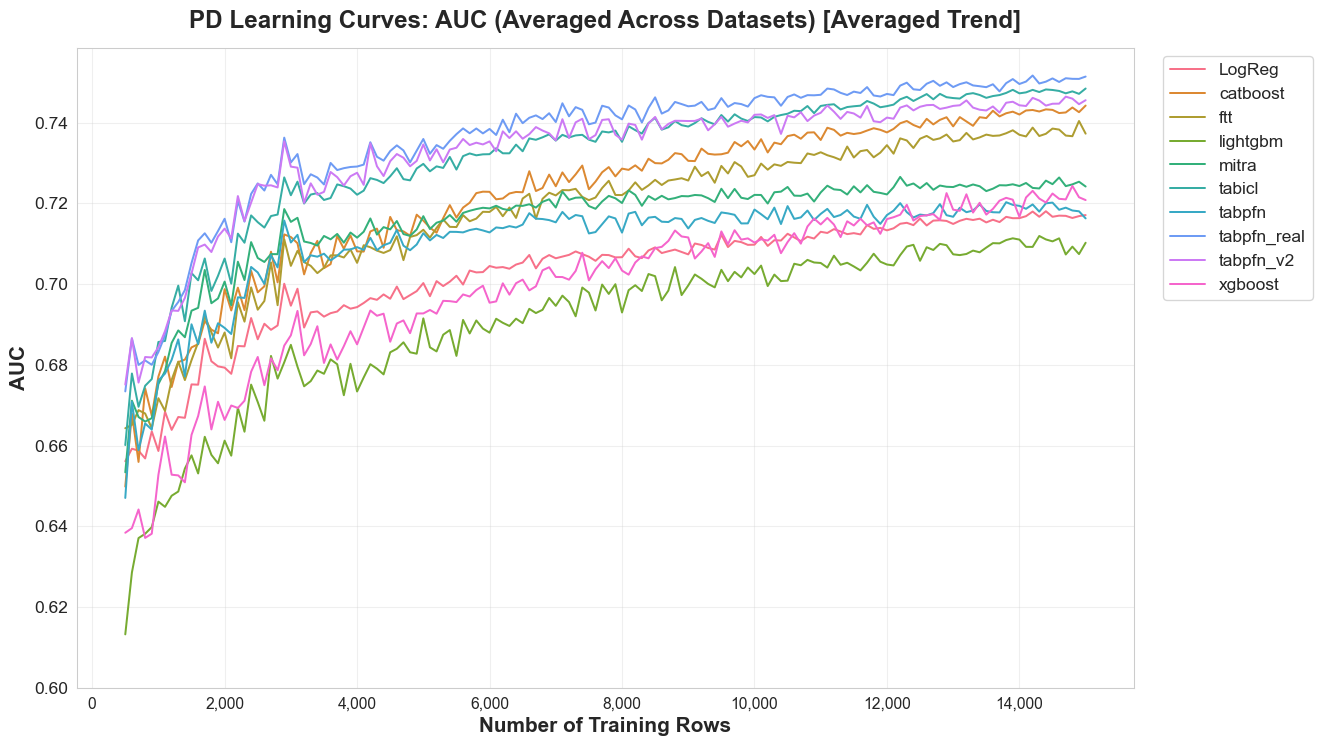


PD F1 Learning Curves [Averaged Trend]
Saved: pd_learning_curve_f1_averaged.png


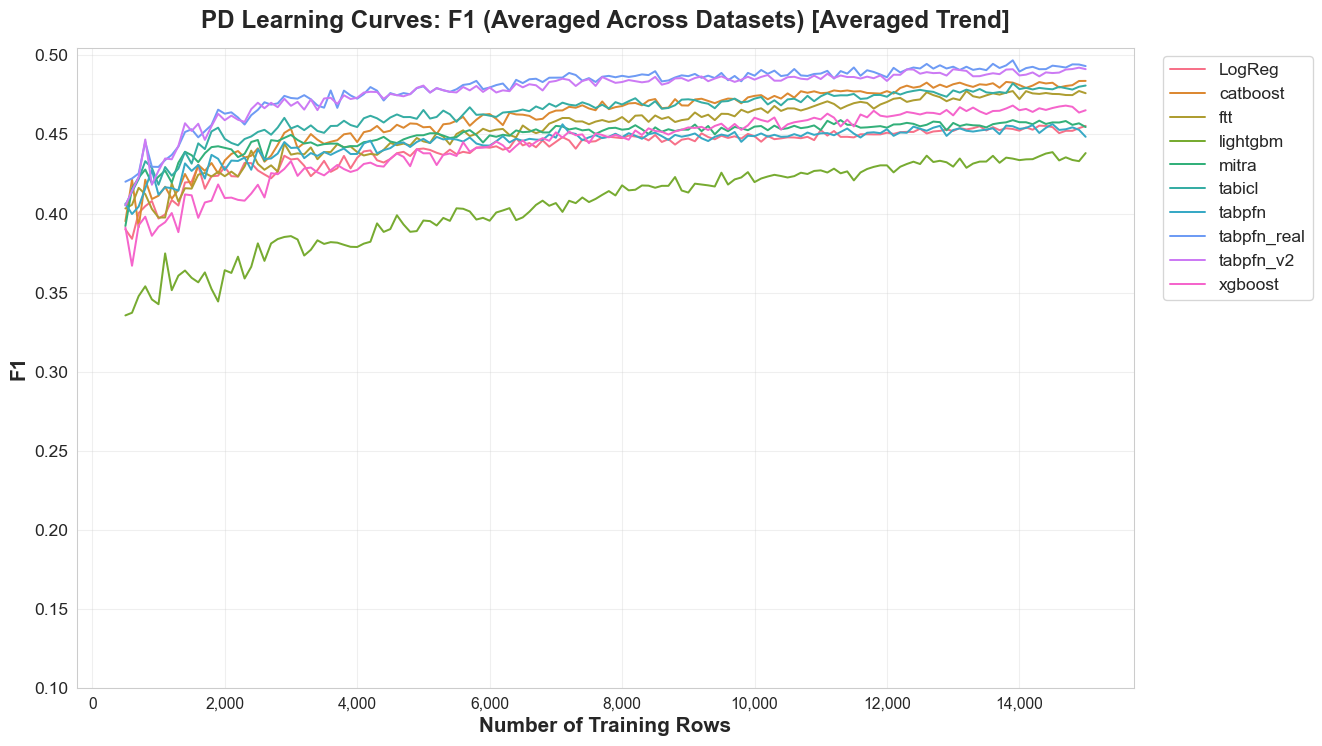


PD Relative Performance Decay [Averaged Trend]
Saved: pd_relative_performance_auc_averaged.png


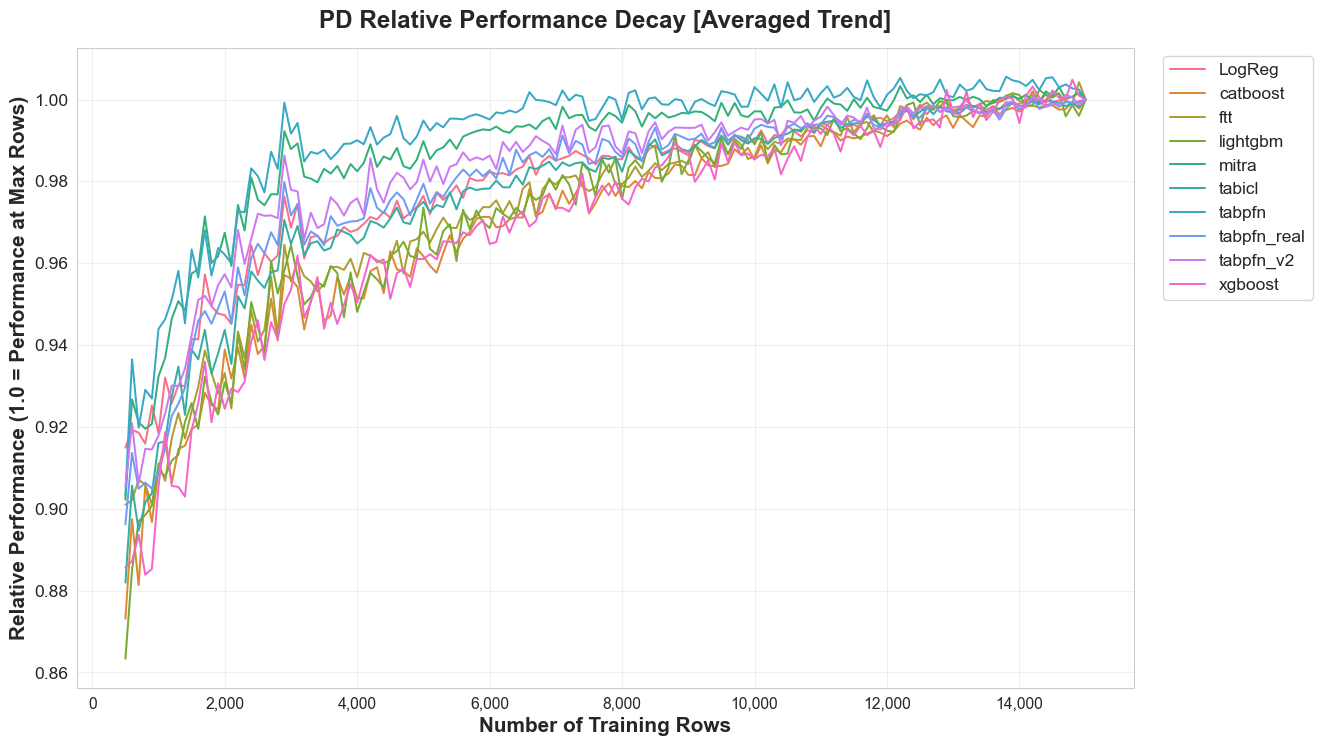


PD Degradation Analysis
Saved: pd_degradation_auc.png


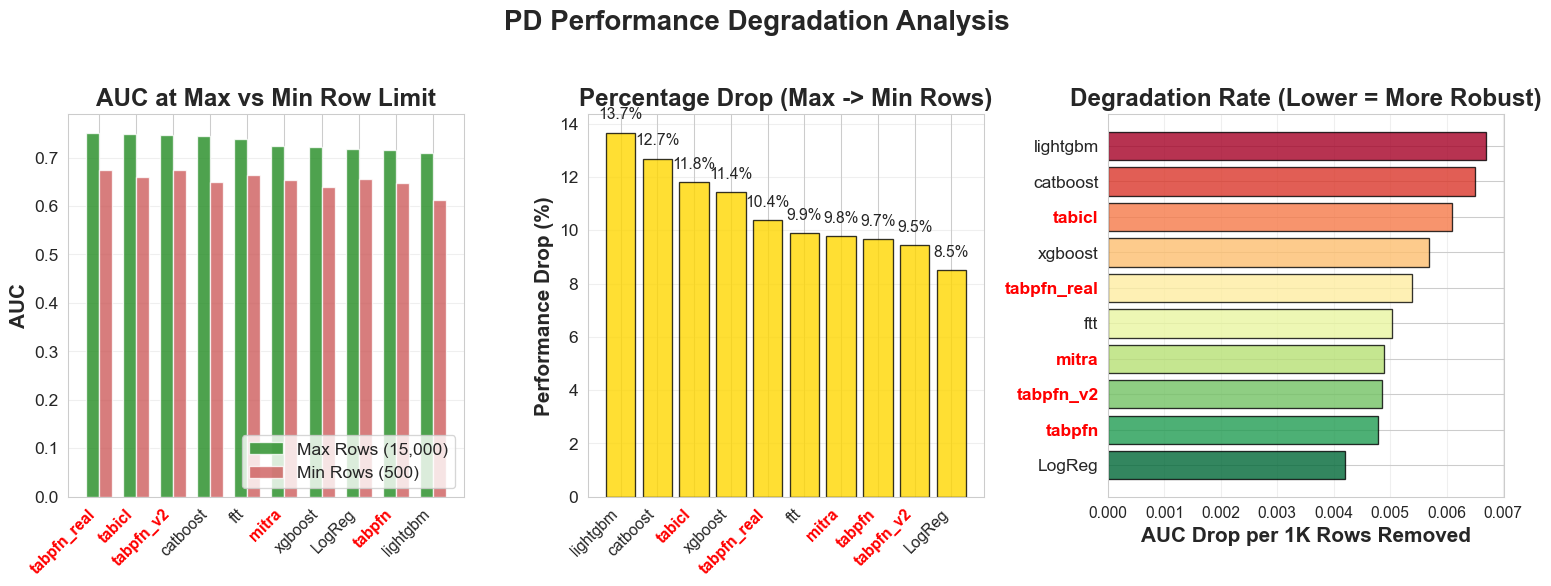


PD AUC Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]
Saved: pd_tabpfnv2_vs_xgboost_diff.png


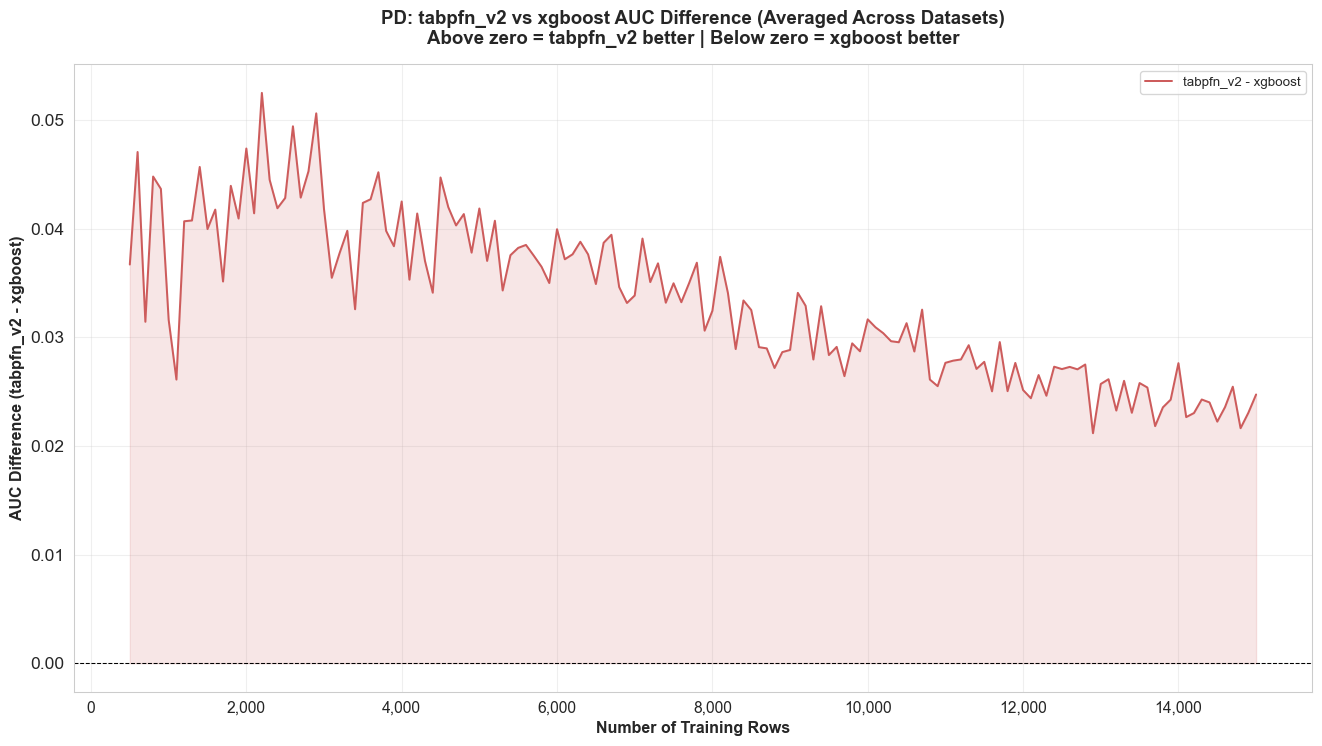

In [12]:
if has_pd and not pd_agg.empty:
    # Averaged AUC learning curve (smooth trend, no dots)
    print("PD AUC Learning Curves [Averaged Trend]")
    plot_learning_curves(pd_agg, 'AUC', 'PD', averaged=True, y_min=0.6)
    plt.show()
    
    # Averaged F1 learning curve
    print("\nPD F1 Learning Curves [Averaged Trend]")
    plot_learning_curves(pd_agg, 'F1', 'PD', averaged=True, y_min=0.1)
    plt.show()
    
    # Averaged Relative Performance Decay
    print("\nPD Relative Performance Decay [Averaged Trend]")
    plot_relative_performance(pd_agg, 'AUC', 'PD', averaged=True)
    plt.show()
    
    # Degradation bar charts
    print("\nPD Degradation Analysis")
    plot_degradation_analysis(pd_degradation, 'AUC', 'PD')
    plt.show()

    # === tabpfn_v2 vs xgboost AUC difference across row limits ===
    print("\nPD AUC Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]")
    mean_col = 'AUC_mean'
    avg_df = pd_agg.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()

    tfn = avg_df[avg_df['method'] == 'tabpfn_v2'].sort_values('row_limit').set_index('row_limit')[mean_col]
    xgb = avg_df[avg_df['method'] == 'xgboost'].sort_values('row_limit').set_index('row_limit')[mean_col]

    if not tfn.empty and not xgb.empty:
        common_limits = sorted(set(tfn.index) & set(xgb.index))
        if common_limits:
            diff = tfn.loc[common_limits] - xgb.loc[common_limits]

            fig, ax = plt.subplots(figsize=(14, 8))
            ax.plot(common_limits, diff.values, '-', color='indianred', linewidth=LINE_WIDTH_THICK,
                    label='tabpfn_v2 - xgboost')
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            ax.fill_between(common_limits, diff.values, 0, where=[d > 0 for d in diff.values],
                            color='indianred', alpha=0.15, interpolate=True)
            ax.fill_between(common_limits, diff.values, 0, where=[d <= 0 for d in diff.values],
                            color='steelblue', alpha=0.15, interpolate=True)
            ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
            ax.set_ylabel('AUC Difference (tabpfn_v2 - xgboost)', fontsize=12, fontweight='bold')
            ax.set_title('PD: tabpfn_v2 vs xgboost AUC Difference (Averaged Across Datasets)\n'
                         'Above zero = tabpfn_v2 better | Below zero = xgboost better',
                         fontsize=14, fontweight='bold', pad=15)
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            filename = FIGURES_DIR / "pd" / "pd_tabpfnv2_vs_xgboost_diff.png"
            plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
            print(f"Saved: {filename.name}")
            plt.show()

### A1.3 Key Methods Comparison (Averaged)

PD AUC Learning Curves - Key Methods [Averaged Trend]
Saved: pd_learning_curve_auc_averaged_key.png


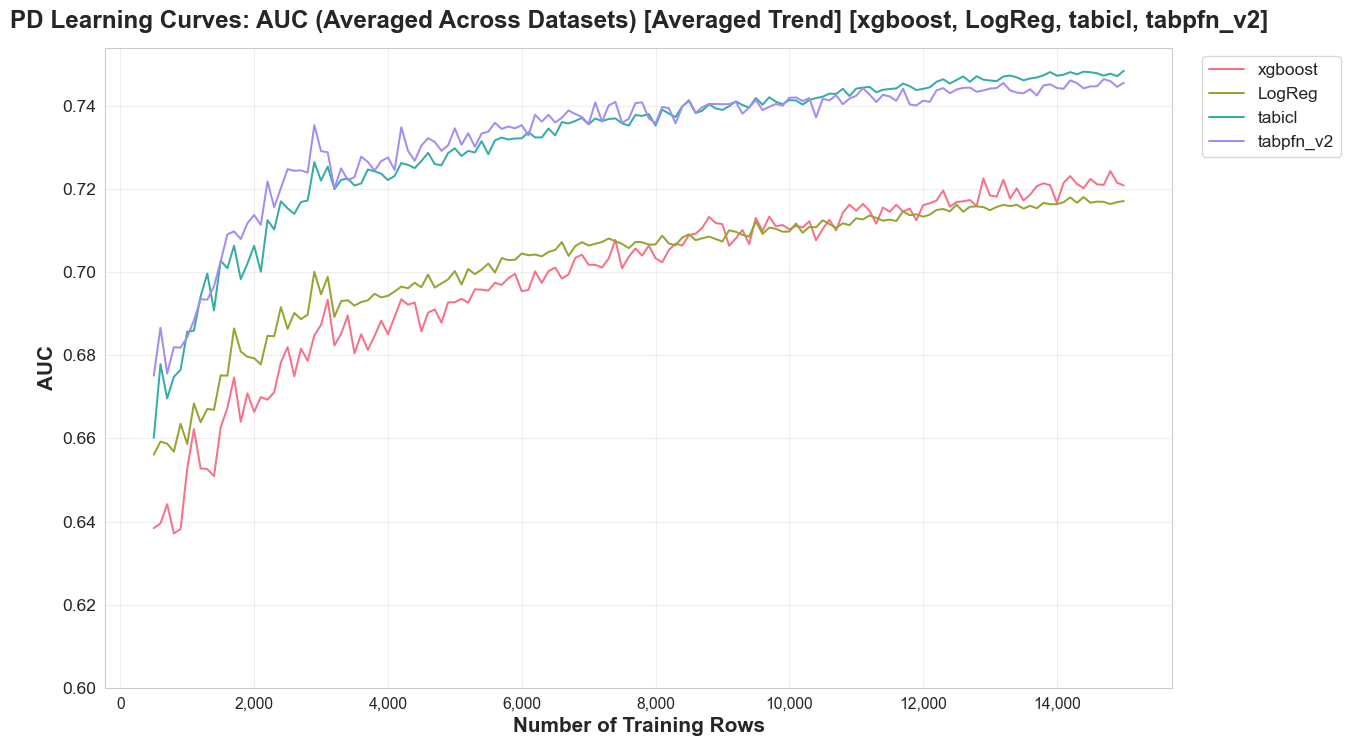


PD F1 Learning Curves - Key Methods [Averaged Trend]
Saved: pd_learning_curve_f1_averaged_key.png


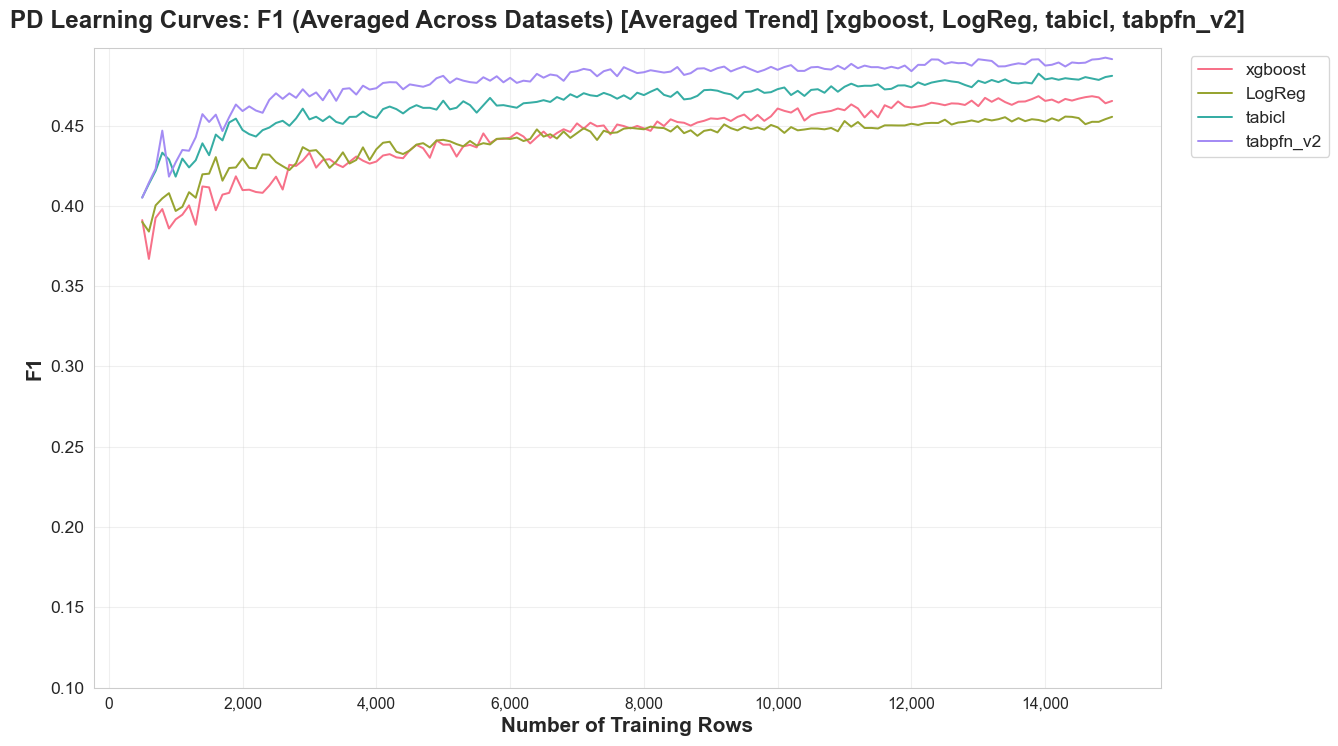


PD Relative Performance Decay - Key Methods [Averaged Trend]
Saved: pd_relative_performance_auc_averaged.png


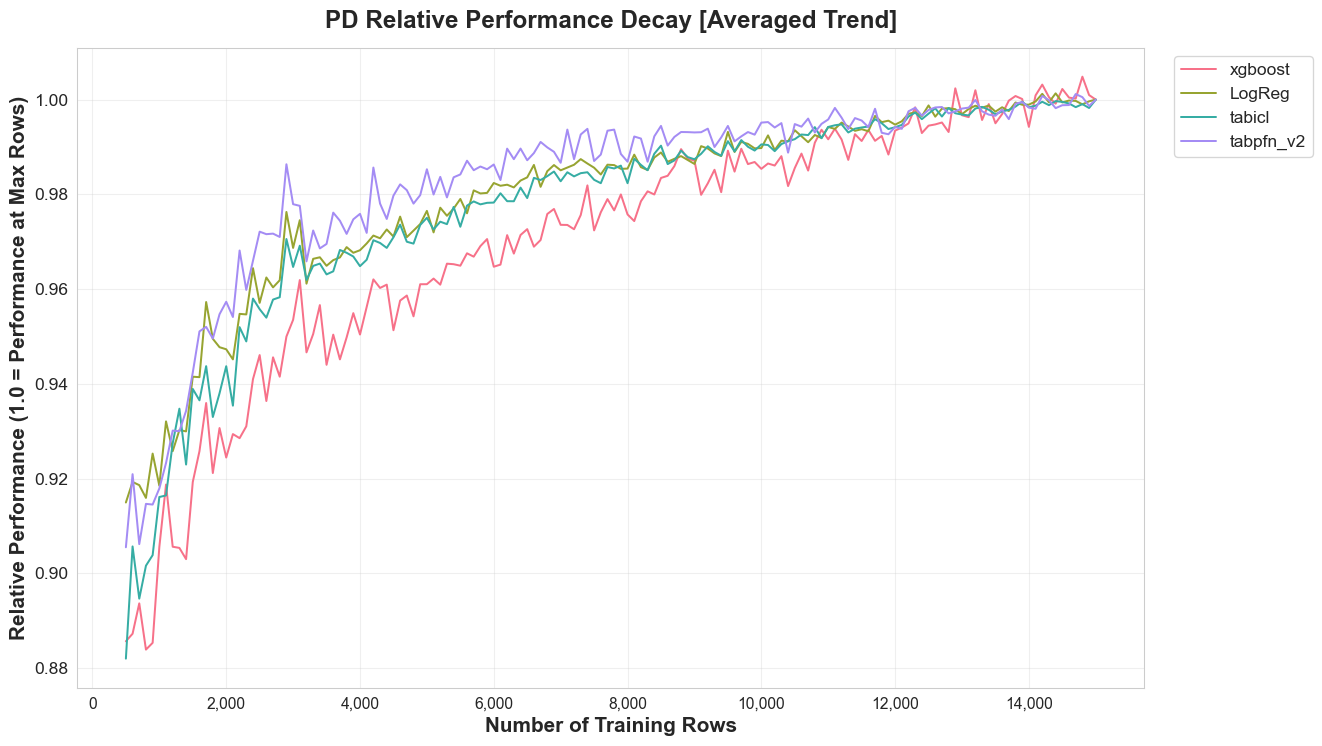

In [13]:
if has_pd and not pd_agg.empty:
    # Key methods AUC (averaged)
    print("PD AUC Learning Curves - Key Methods [Averaged Trend]")
    plot_learning_curves(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True, y_min=0.6)
    plt.show()
    
    # Key methods F1 (averaged)
    print("\nPD F1 Learning Curves - Key Methods [Averaged Trend]")
    plot_learning_curves(pd_agg, 'F1', 'PD', methods=PD_KEY_METHODS, averaged=True, y_min=0.1)
    plt.show()
    
    # Key methods Relative Performance Decay (averaged)
    print("\nPD Relative Performance Decay - Key Methods [Averaged Trend]")
    plot_relative_performance(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True)
    plt.show()

## A2. Rank Analysis

PD Rank Evolution [Averaged Trend]
Saved: pd_rank_evolution_auc_averaged.png


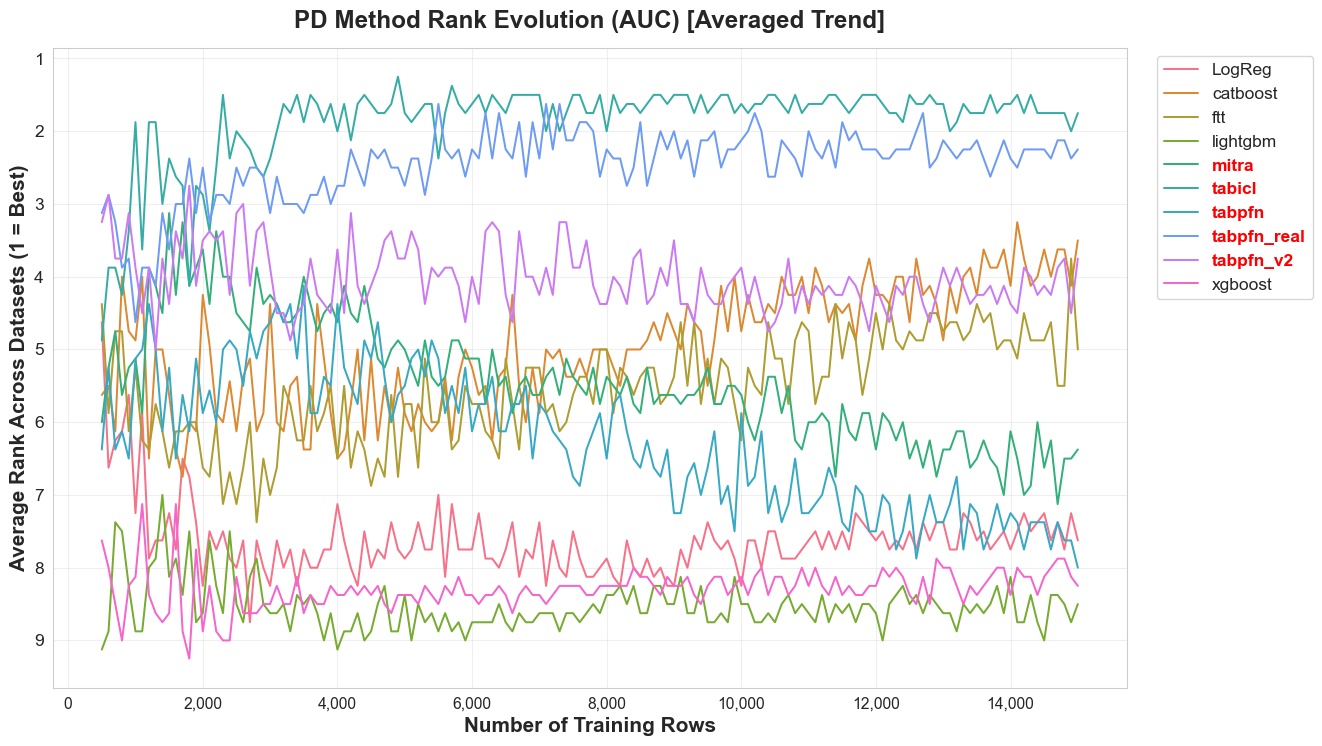


PD Rank Evolution - Key Methods [Averaged Trend]
Saved: pd_rank_evolution_auc_averaged_key.png


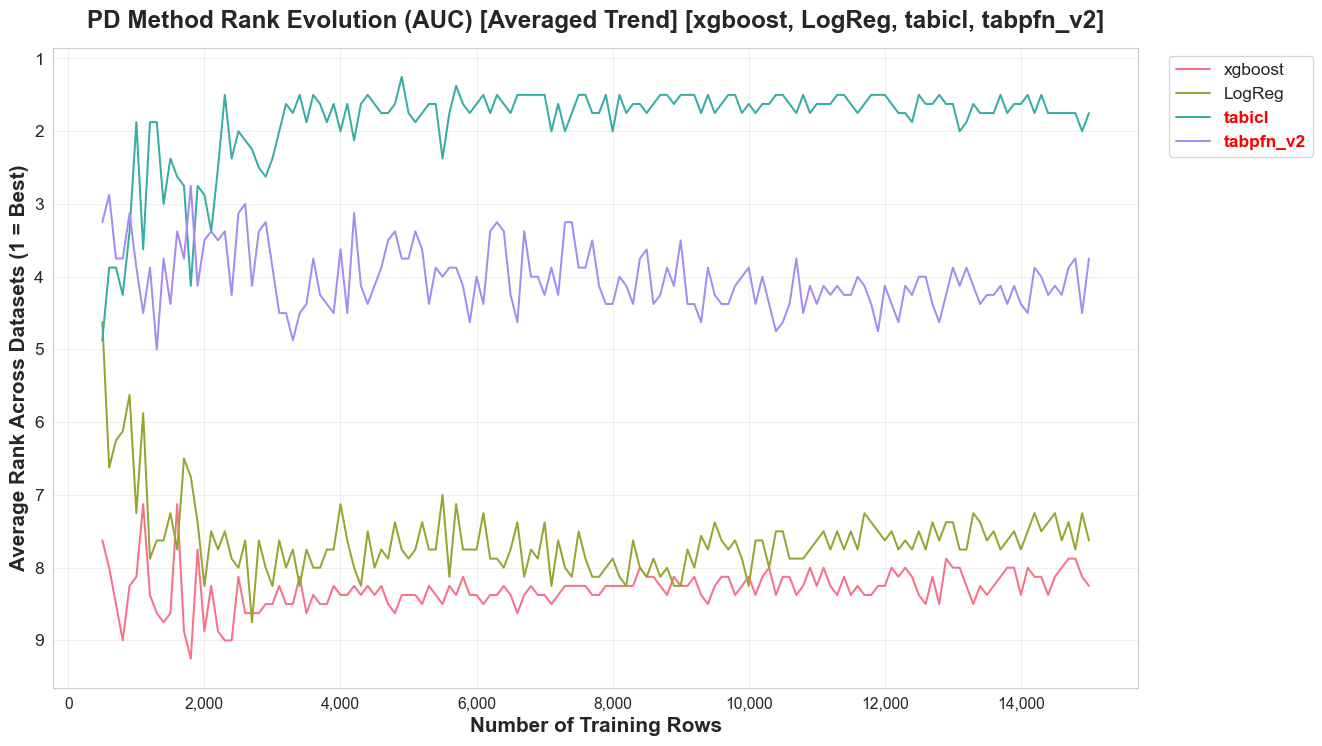


PD Spearman Rank Correlation
Saved: pd_spearman_rank_auc.png


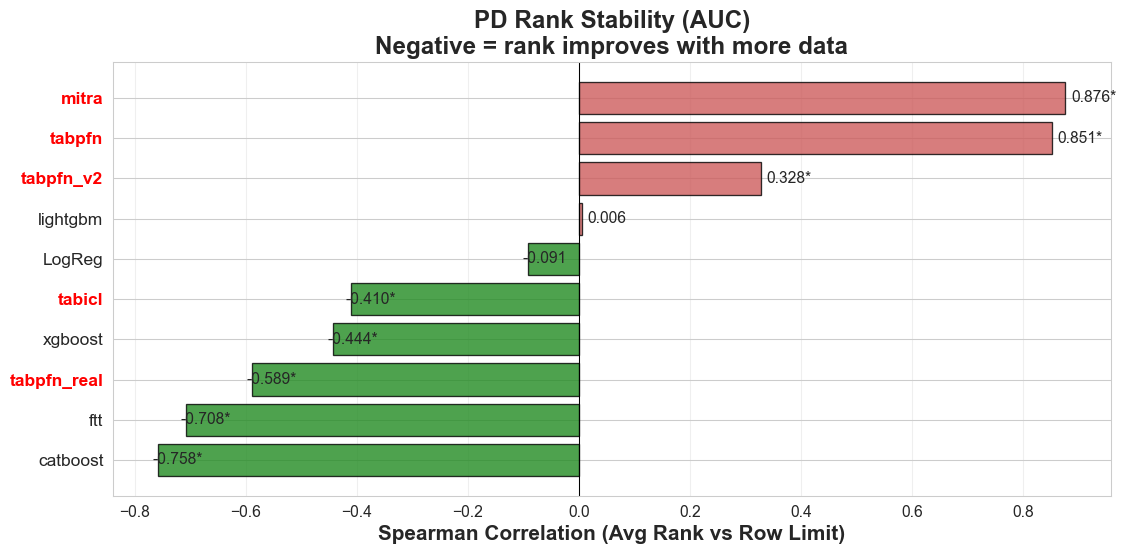


PD Performance Scaling (Pearson)
Saved: pd_pearson_metric_auc.png


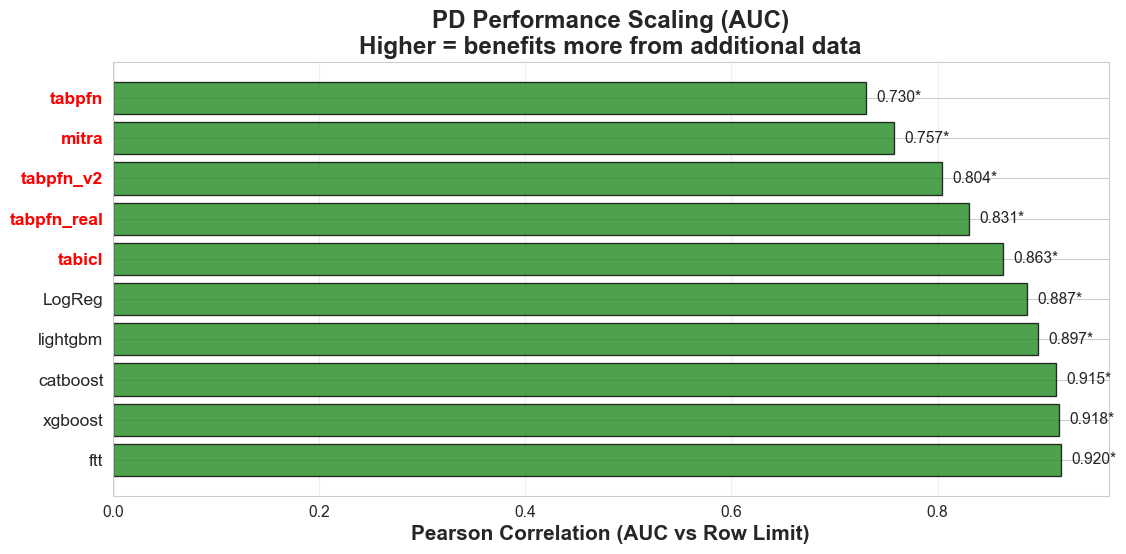

In [14]:
if has_pd and not pd_agg.empty:
    # Rank evolution across row_limits (all methods, averaged trend)
    print("PD Rank Evolution [Averaged Trend]")
    plot_rank_evolution(pd_agg, 'AUC', 'PD', averaged=True)
    plt.show()
    
    # Rank evolution - key methods only (averaged trend)
    print("\nPD Rank Evolution - Key Methods [Averaged Trend]")
    plot_rank_evolution(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, averaged=True)
    plt.show()
    
    # Spearman rank correlation
    print("\nPD Spearman Rank Correlation")
    plot_spearman_rank_correlation(pd_agg, 'AUC', 'PD')
    plt.show()
    
    # Pearson AUC vs row_limit correlation
    print("\nPD Performance Scaling (Pearson)")
    plot_metric_vs_rowlimit_correlation(pd_agg, 'AUC', 'PD')
    plt.show()

## A3. Per-Dataset Analysis

Generating per-dataset learning curves for 8 PD datasets...

Dataset: 0001.gmsc
Saved: pd_learning_curve_auc_0001_gmsc_averaged.png


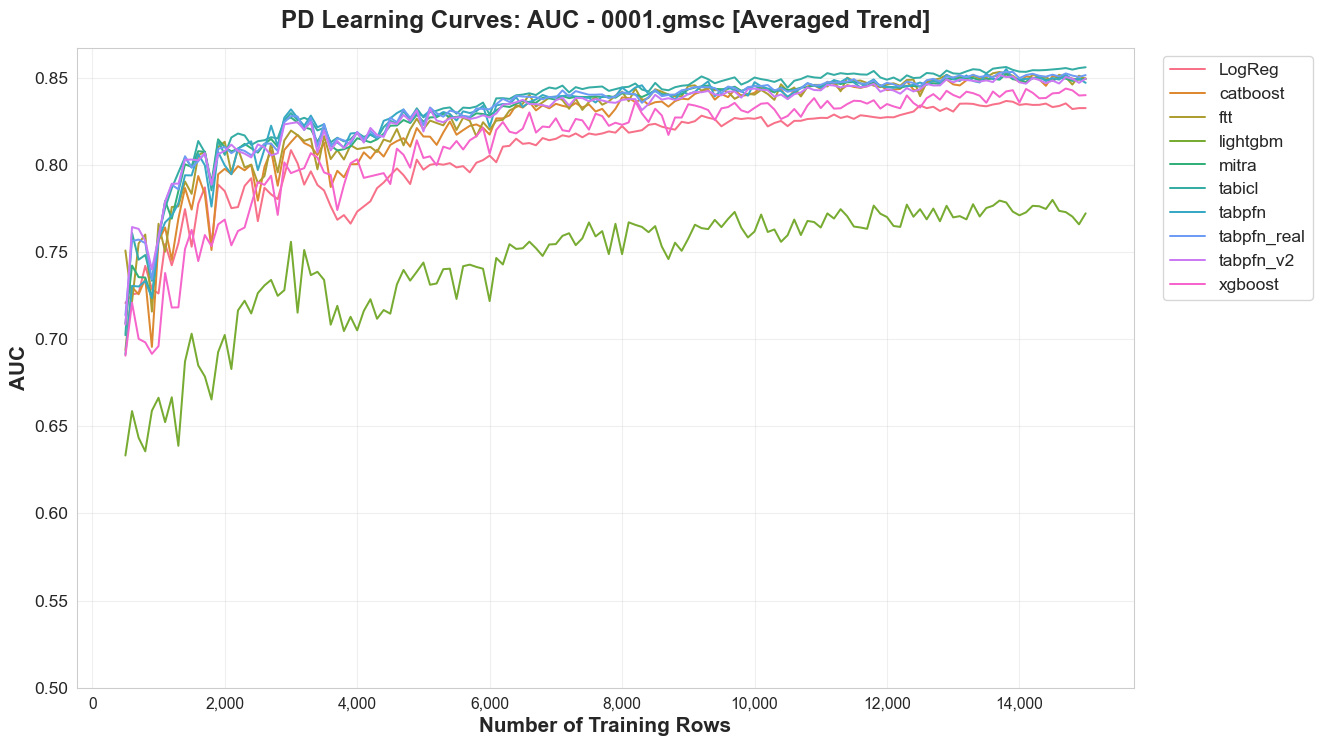

Saved: pd_learning_curve_auc_0001_gmsc_averaged_key.png


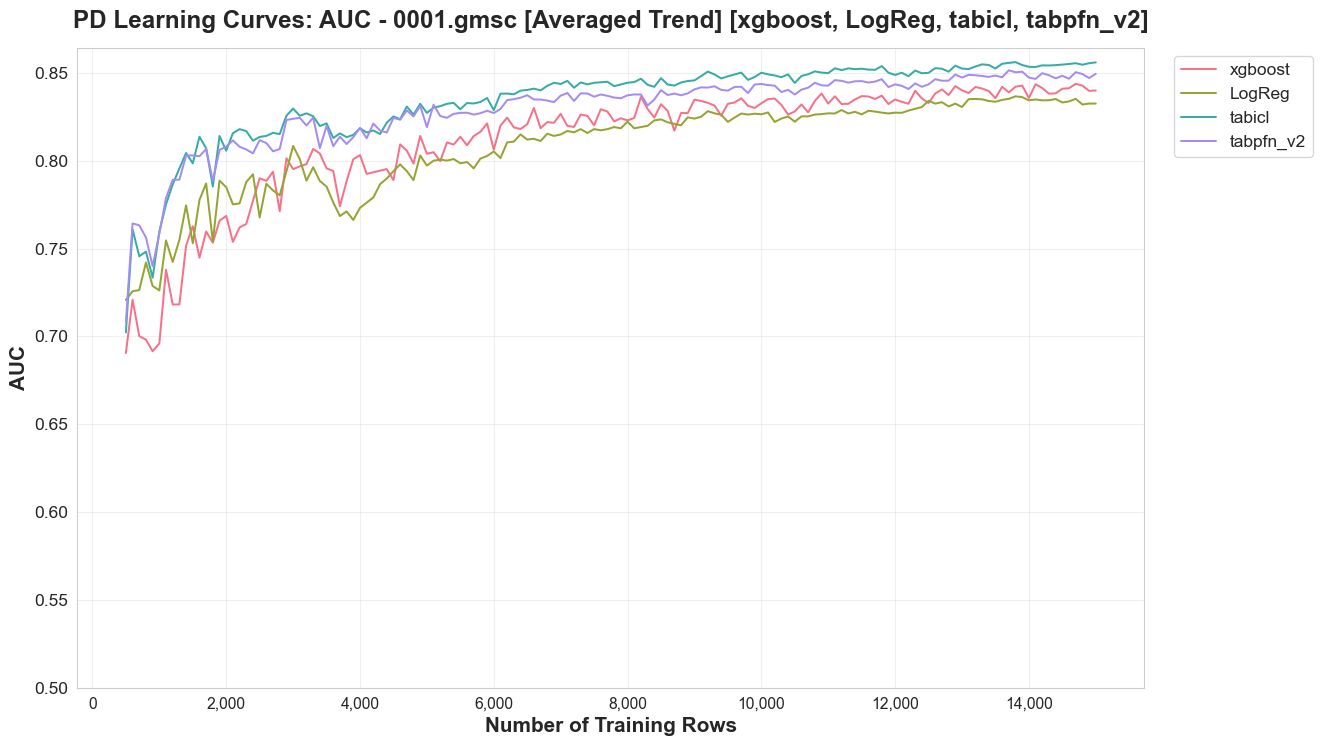

Dataset: 0002.taiwan_creditcard
Saved: pd_learning_curve_auc_0002_taiwan_creditcard_averaged.png


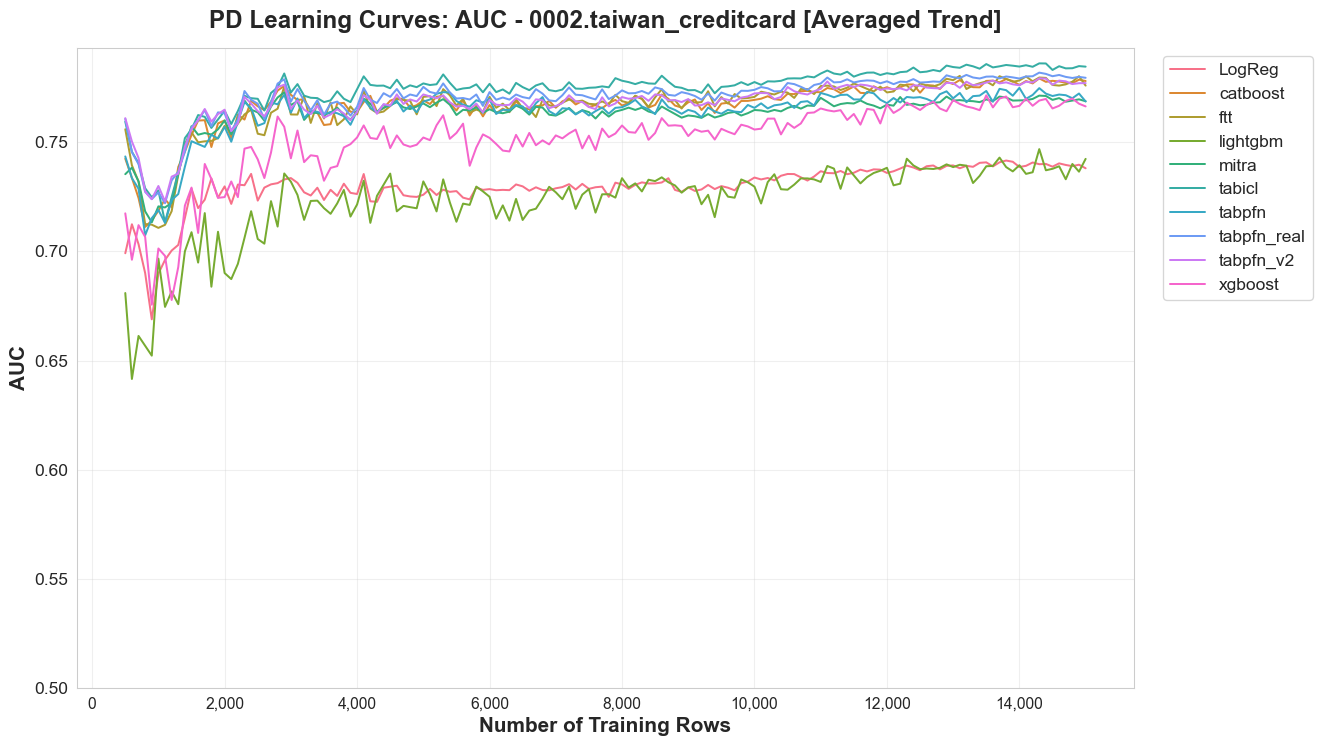

Saved: pd_learning_curve_auc_0002_taiwan_creditcard_averaged_key.png


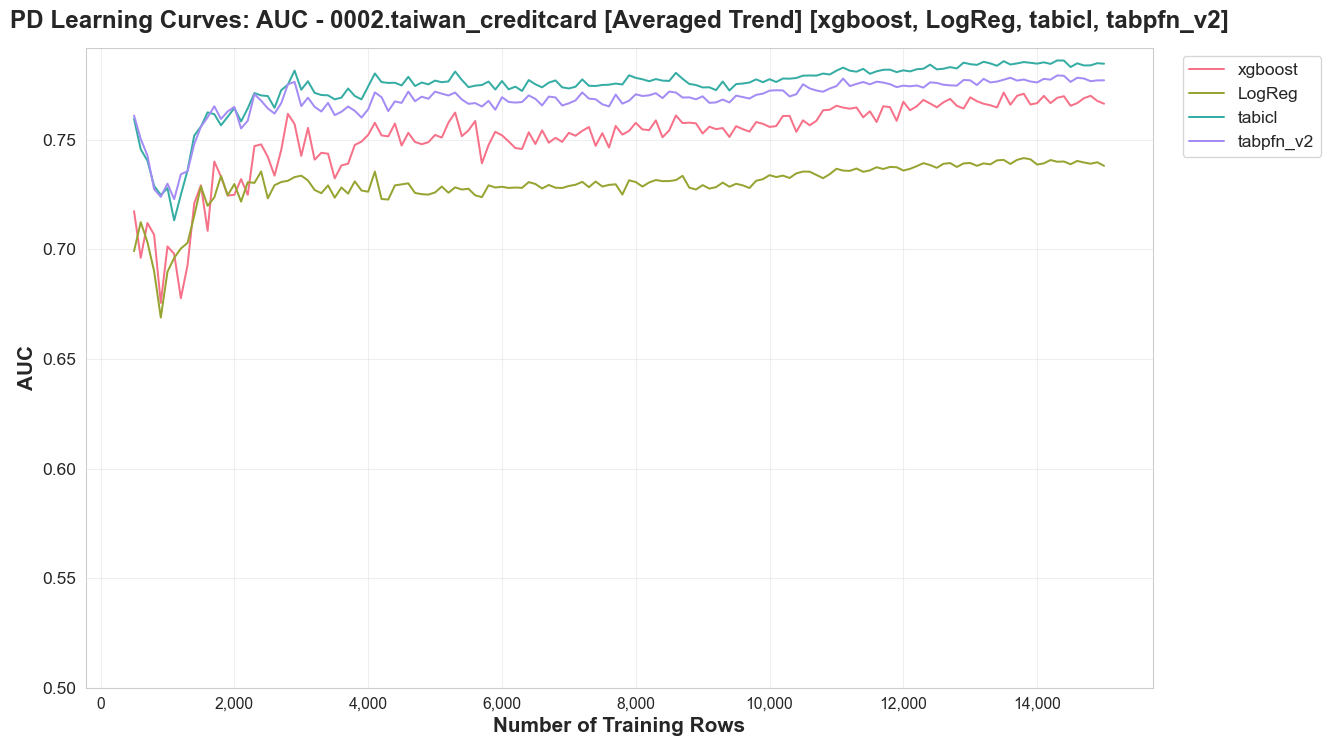

Dataset: 0003.vehicle_loan
Saved: pd_learning_curve_auc_0003_vehicle_loan_averaged.png


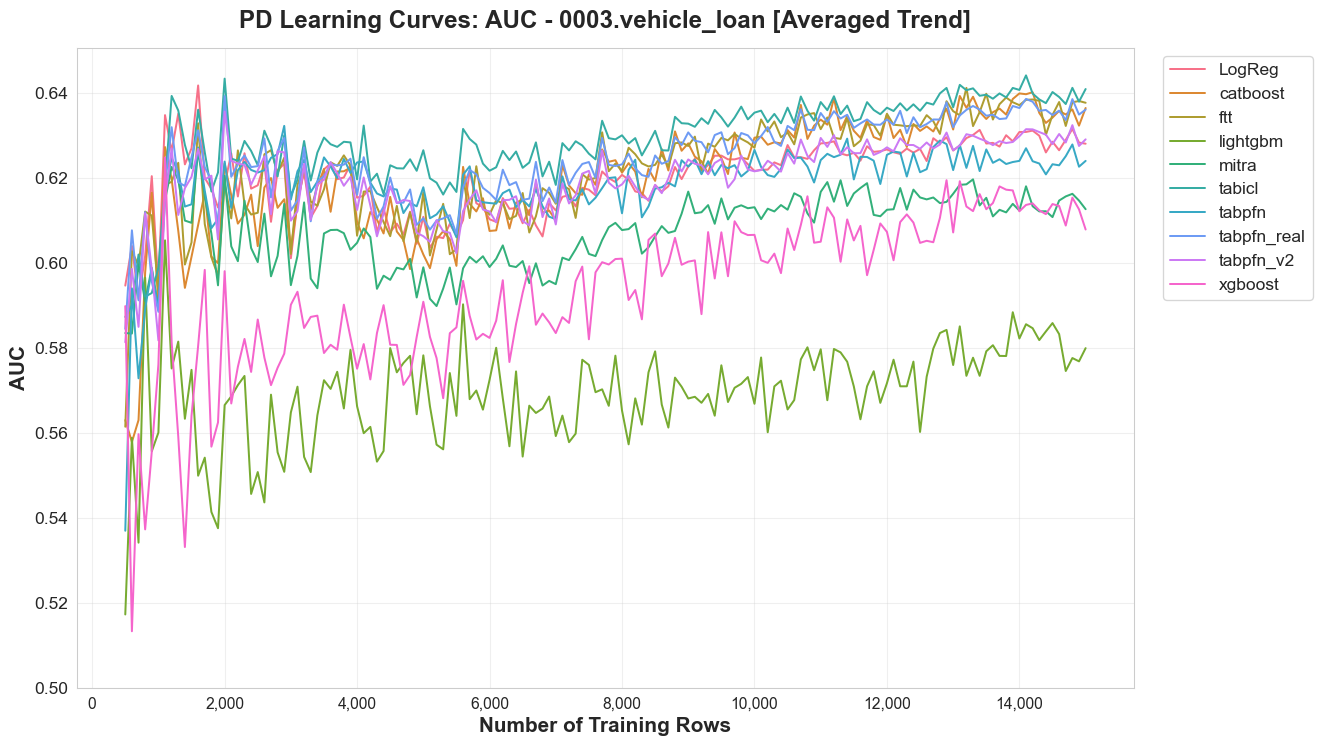

Saved: pd_learning_curve_auc_0003_vehicle_loan_averaged_key.png


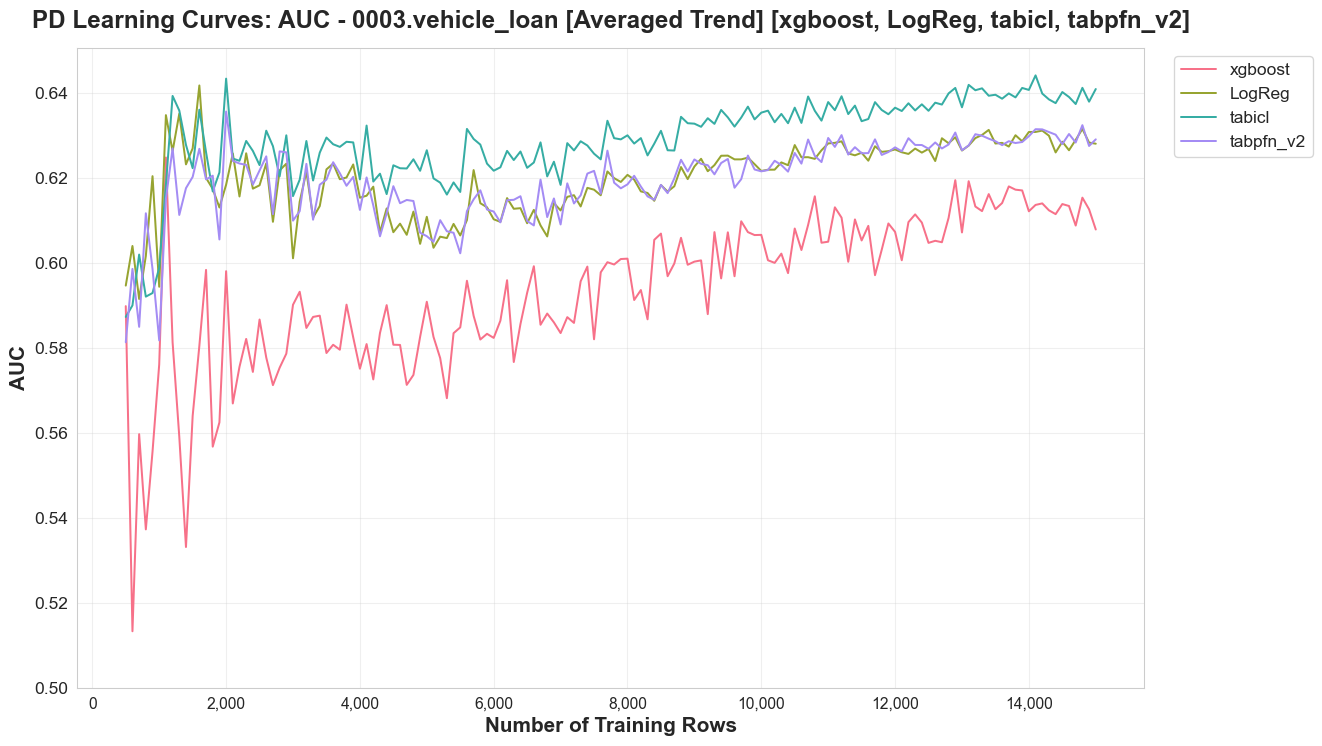

Dataset: 0006.hackerearth
Saved: pd_learning_curve_auc_0006_hackerearth_averaged.png


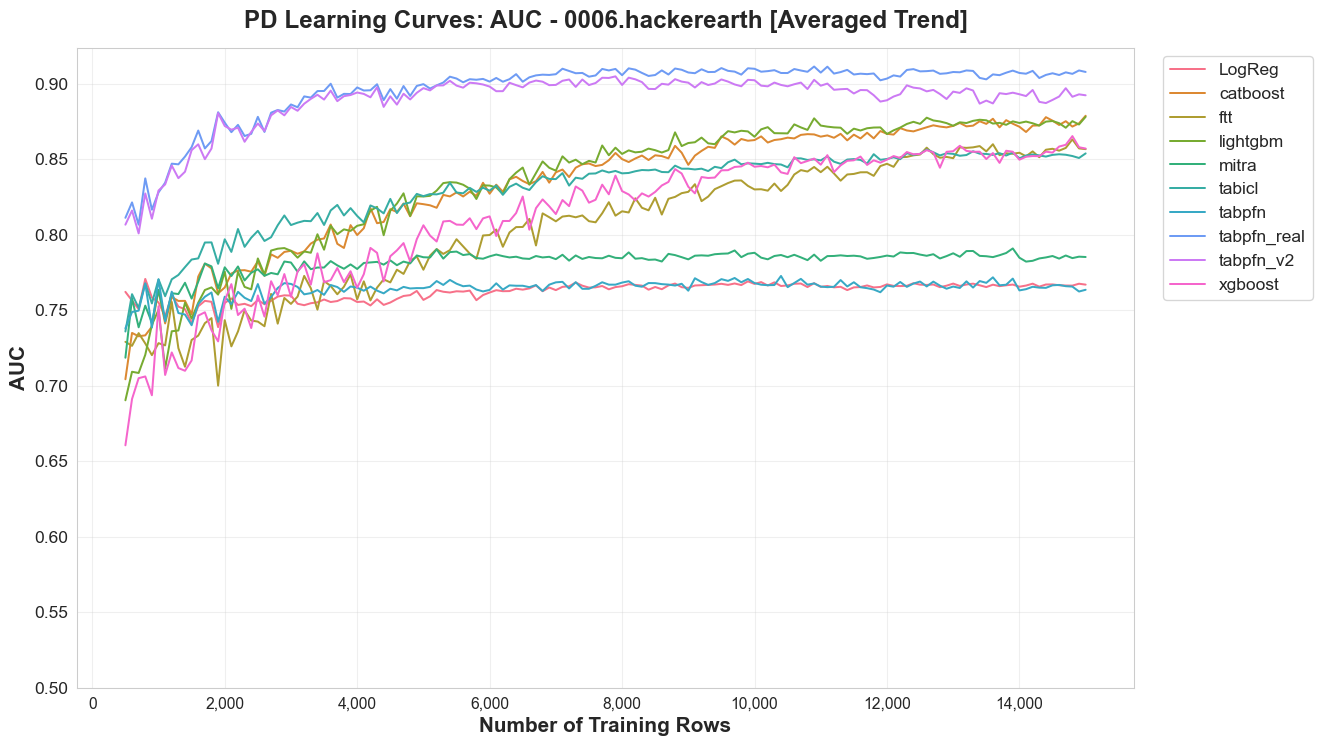

Saved: pd_learning_curve_auc_0006_hackerearth_averaged_key.png


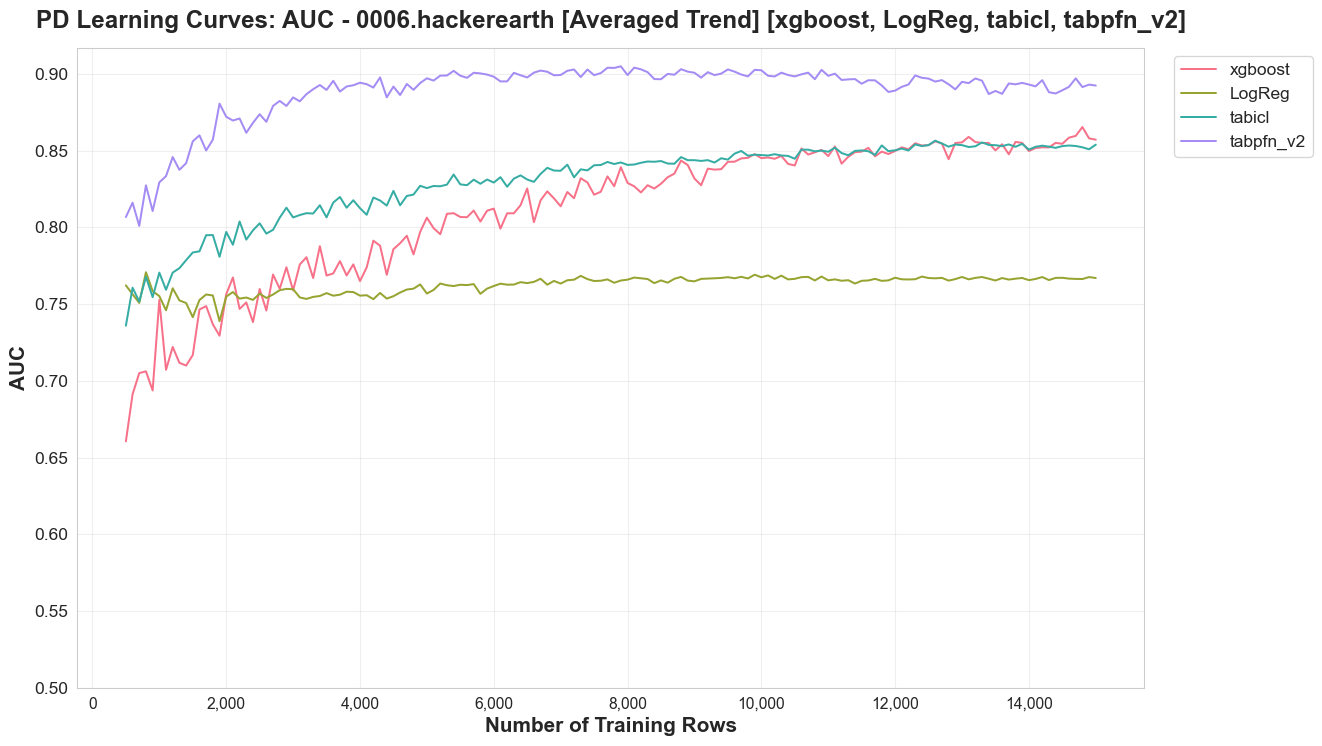

Dataset: 0007.cobranded
Saved: pd_learning_curve_auc_0007_cobranded_averaged.png


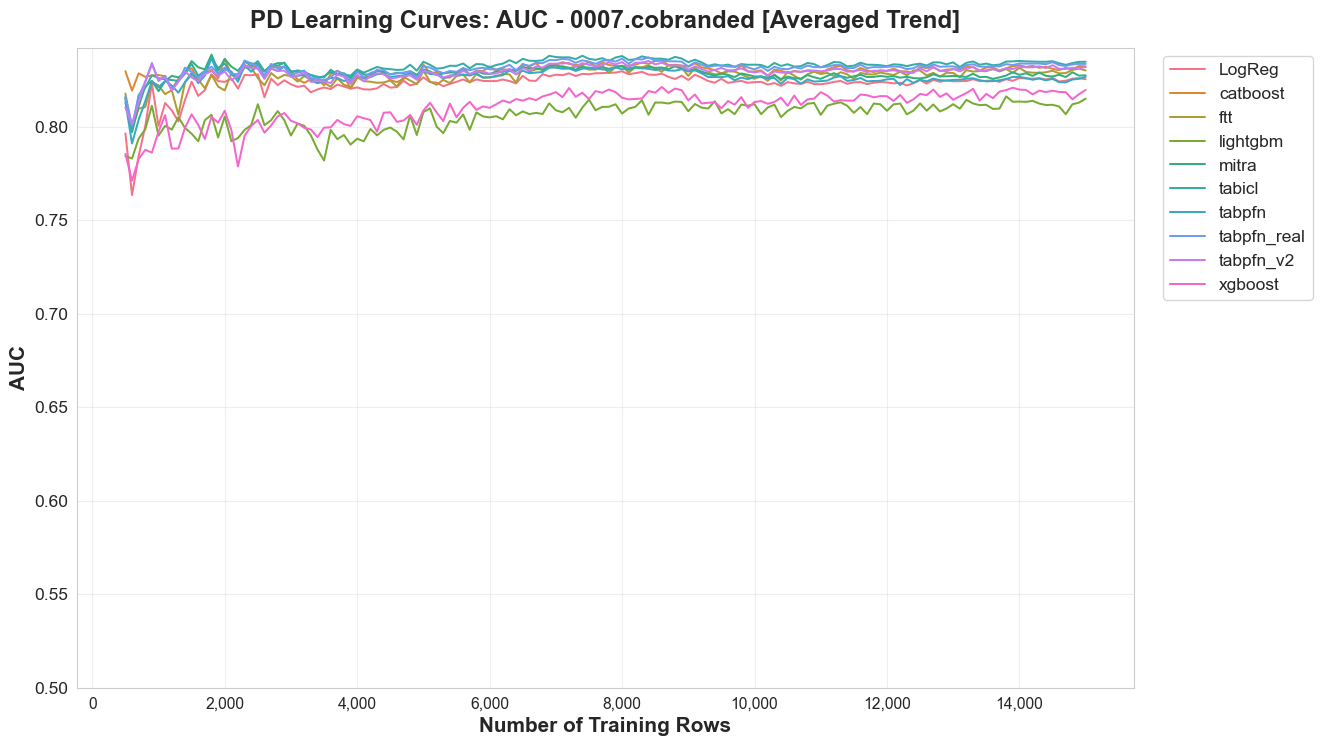

Saved: pd_learning_curve_auc_0007_cobranded_averaged_key.png


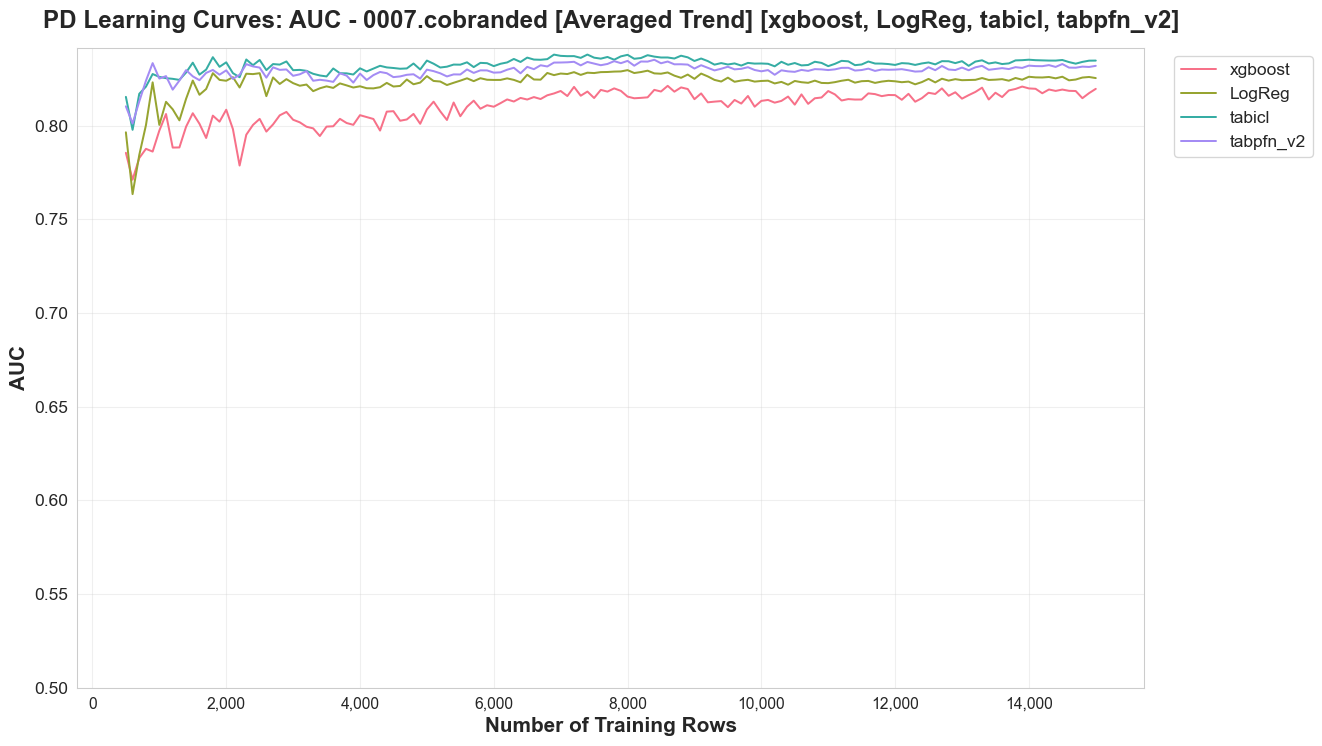

Dataset: 0009.bank_status
Saved: pd_learning_curve_auc_0009_bank_status_averaged.png


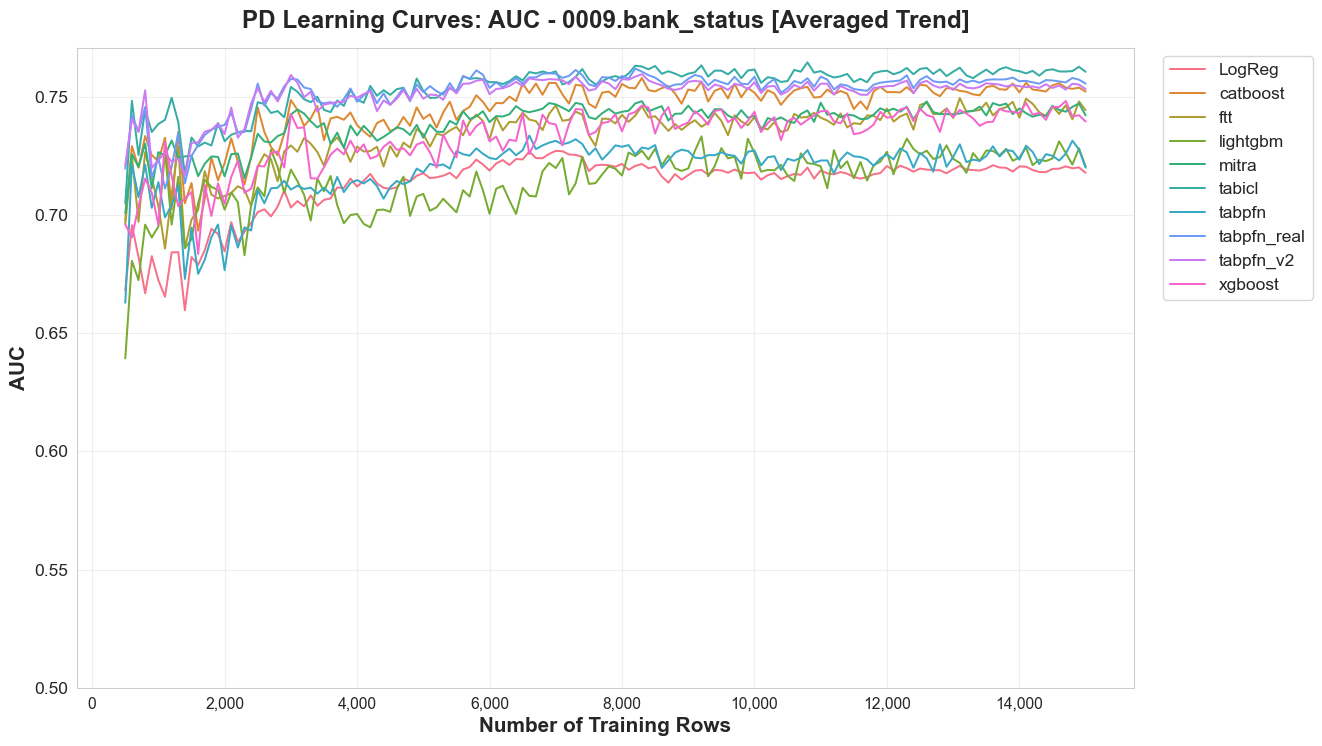

Saved: pd_learning_curve_auc_0009_bank_status_averaged_key.png


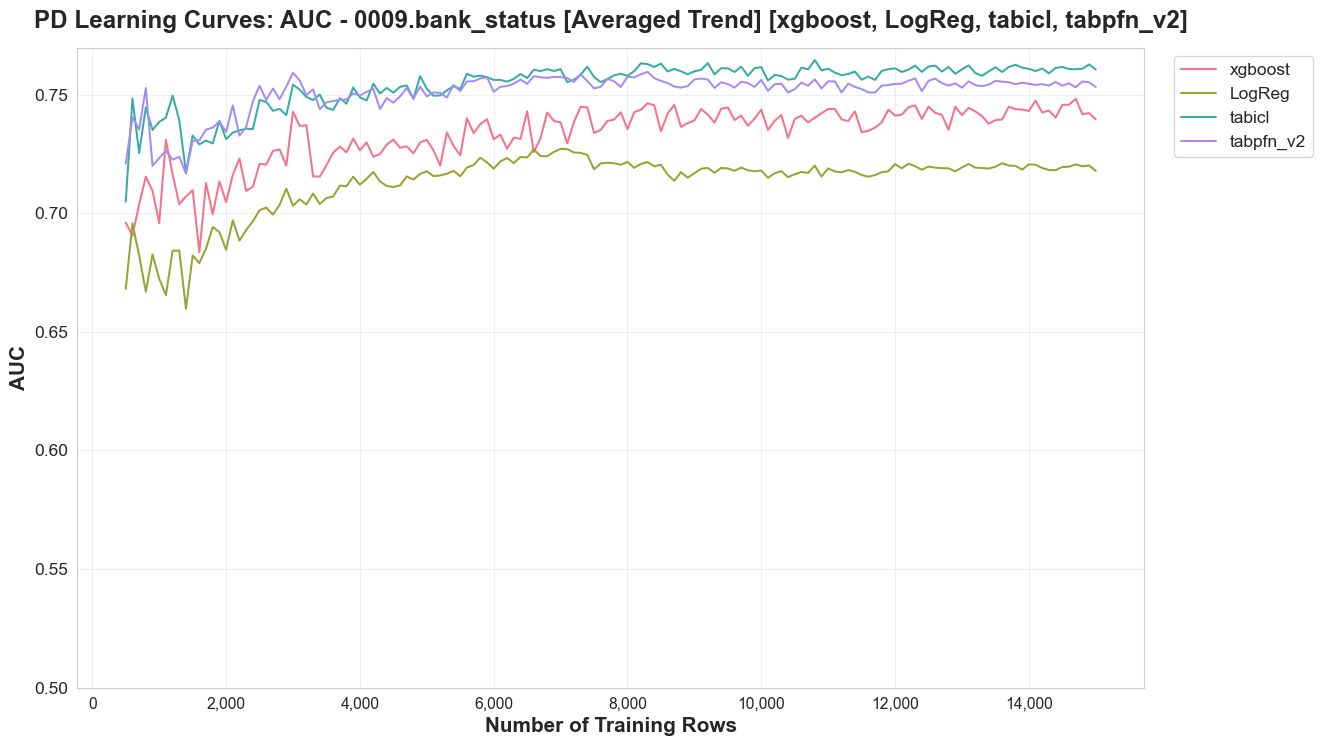

Dataset: 0011.loan_default
Saved: pd_learning_curve_auc_0011_loan_default_averaged.png


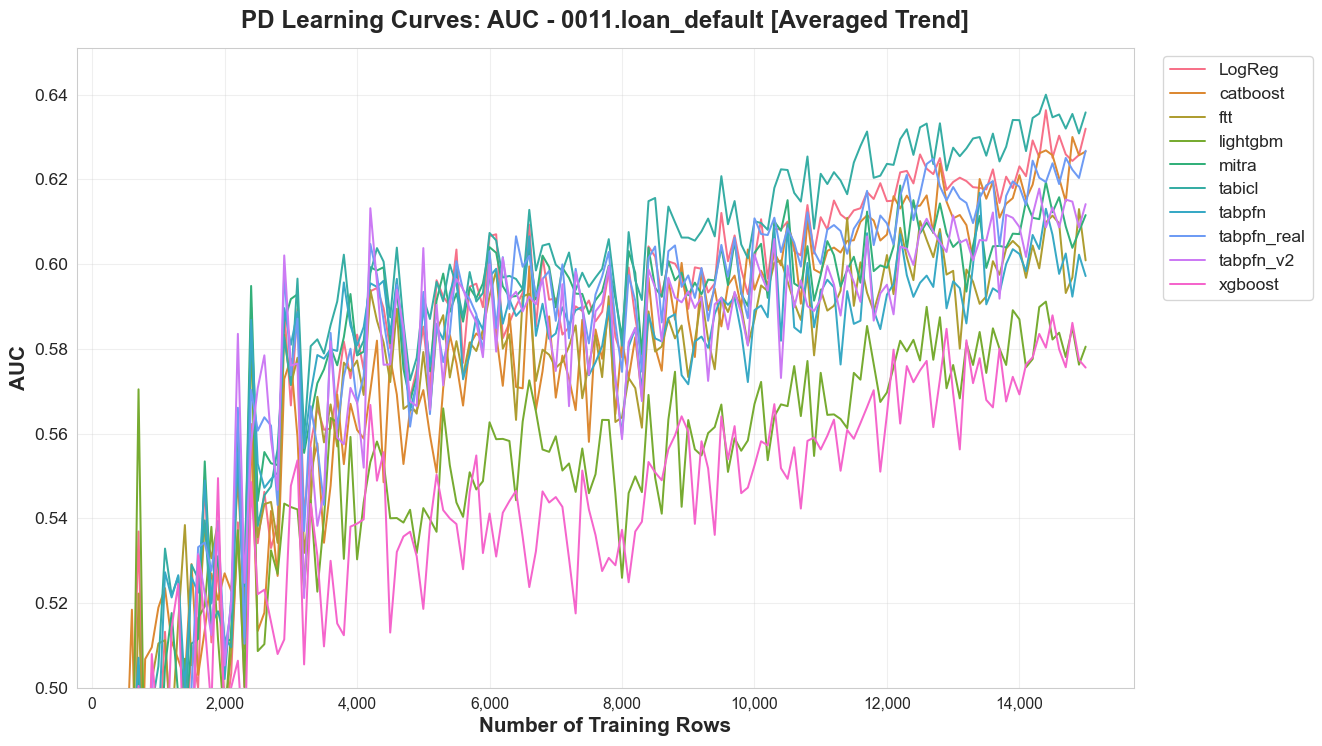

Saved: pd_learning_curve_auc_0011_loan_default_averaged_key.png


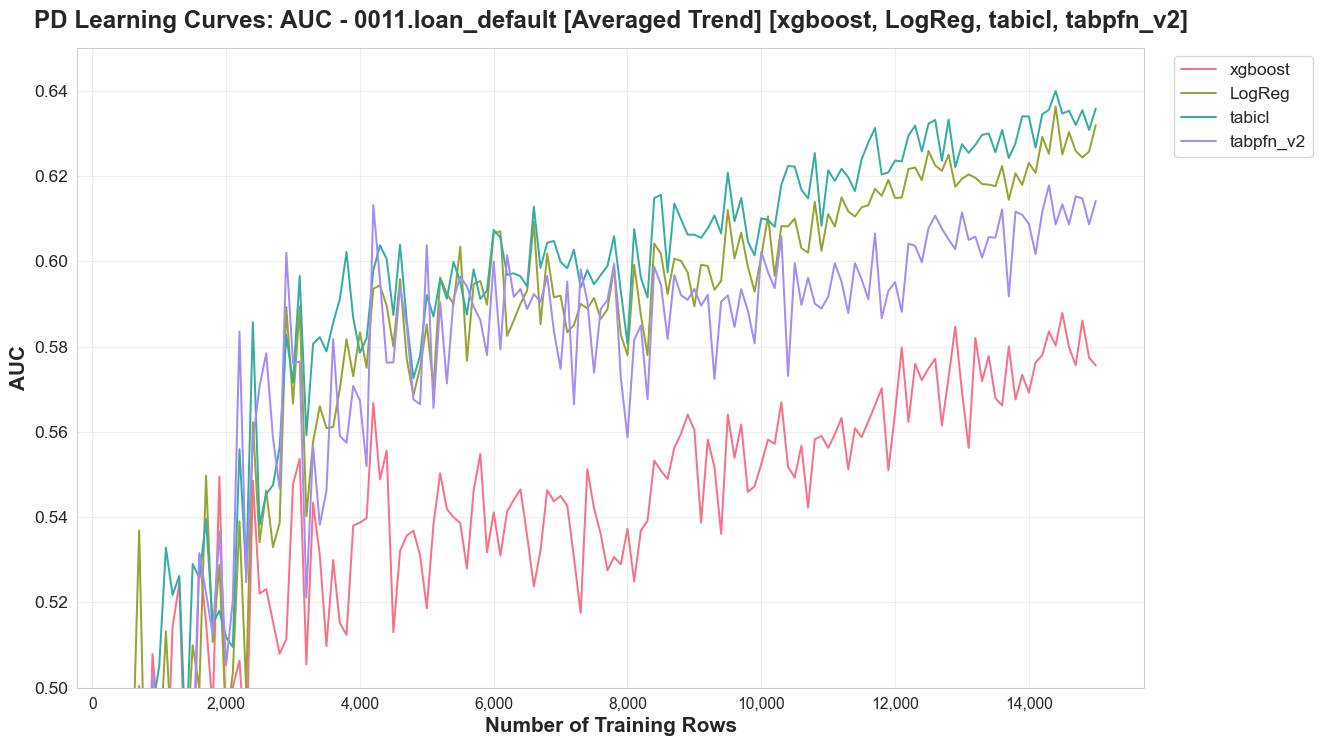

Dataset: 0014.algorithmwatch
Saved: pd_learning_curve_auc_0014_algorithmwatch_averaged.png


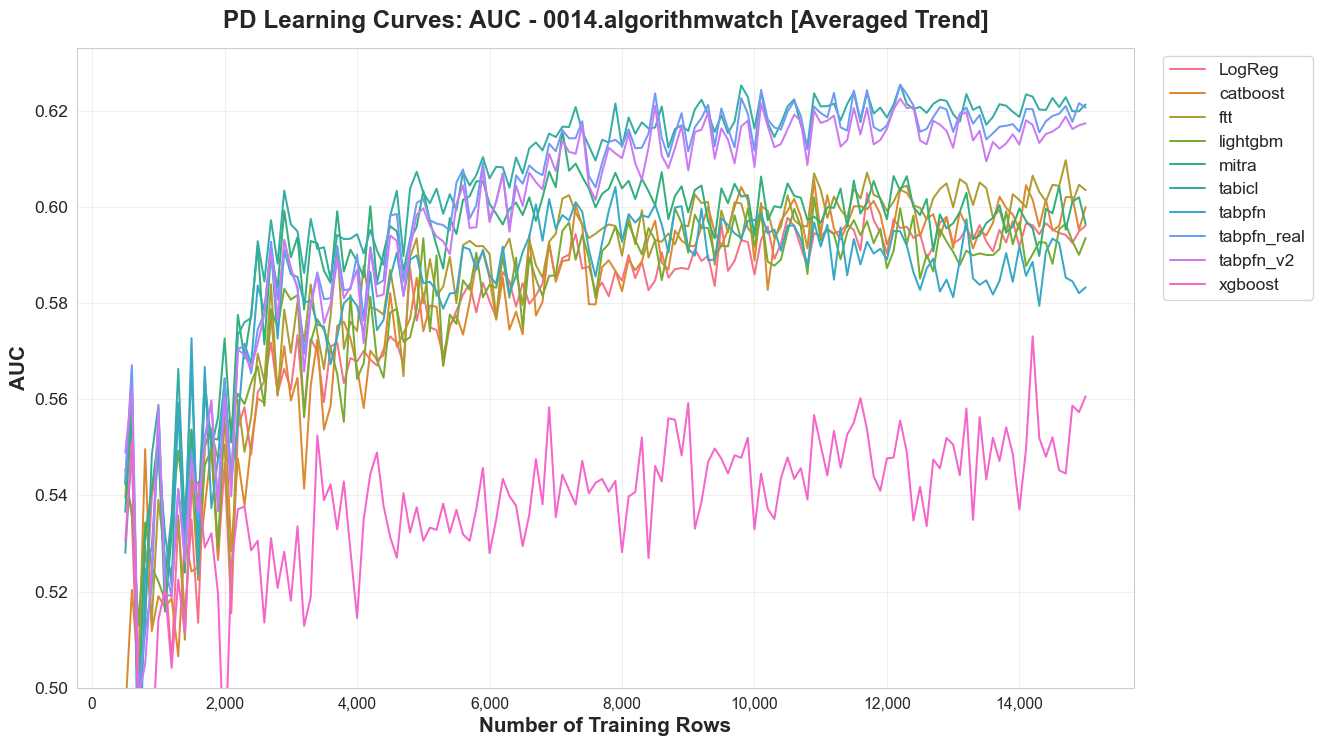

Saved: pd_learning_curve_auc_0014_algorithmwatch_averaged_key.png


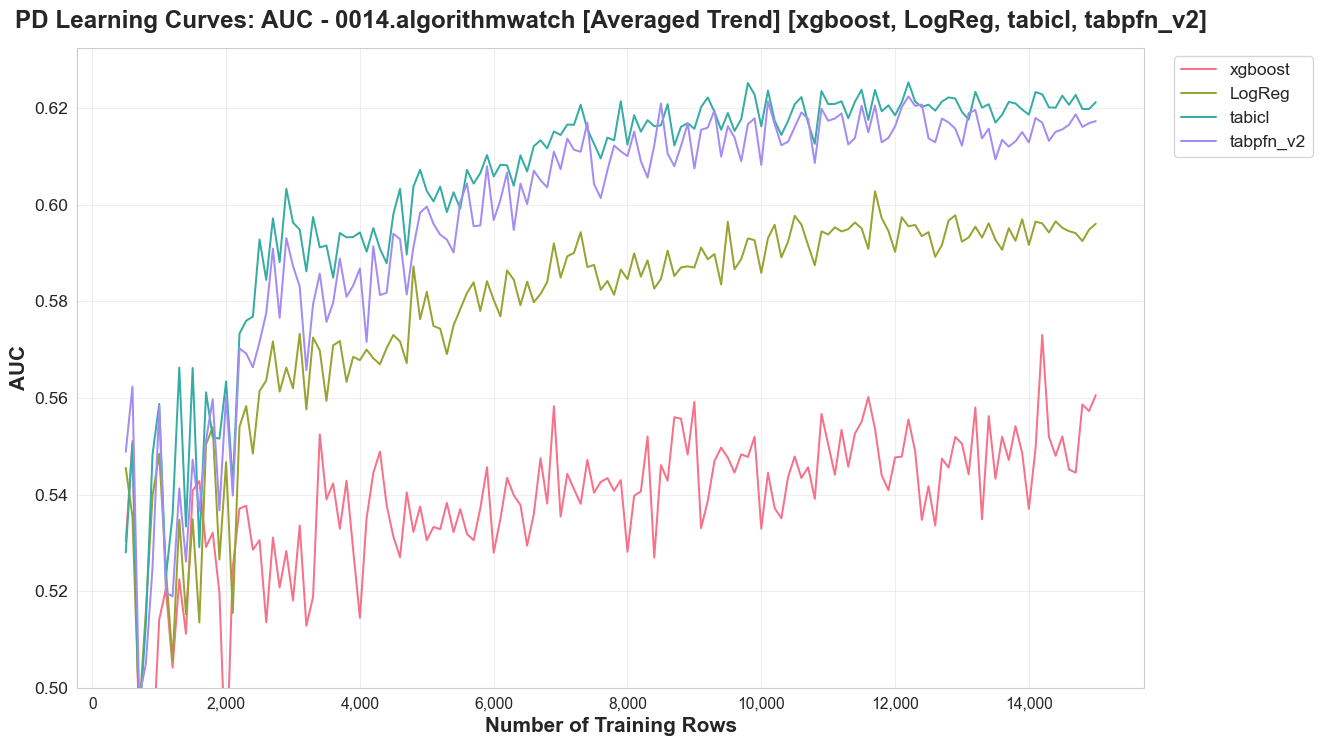

In [15]:
if has_pd and not pd_agg.empty:
    datasets = sorted(pd_agg['dataset'].unique())
    print(f"Generating per-dataset learning curves for {len(datasets)} PD datasets...\n")
    
    for dataset in datasets:
        print(f"{'='*60}")
        print(f"Dataset: {dataset}")
        print(f"{'='*60}")
        
        # All methods (averaged trend)
        plot_learning_curves(pd_agg, 'AUC', 'PD', dataset=dataset, averaged=True, y_min=0.5)
        plt.show()
        
        # Key methods only (averaged trend)
        plot_learning_curves(pd_agg, 'AUC', 'PD', methods=PD_KEY_METHODS, dataset=dataset, averaged=True, y_min=0.5)
        plt.show()

---

# Part B: LGD (Loss Given Default) Analysis

---

## B1. General Statistics & Averaged Graphs

### B1.1 Degradation Statistics

In [16]:
if has_lgd and not lgd_agg.empty:
    lgd_degradation = calculate_degradation(lgd_agg, 'R2', 'LGD')
    
    print("\n" + "=" * 80)
    print("  LGD DEGRADATION ANALYSIS (R2)")
    print("=" * 80)
    print("\nMethods sorted by performance at maximum row limit:")
    display(lgd_degradation.round(4))
    
    print("\nMost ROBUST (lowest % drop):")
    print(lgd_degradation.nsmallest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))
    
    print("\nLEAST robust (highest % drop):")
    print(lgd_degradation.nlargest(5, 'pct_drop')[['method', 'R2_at_max', 'R2_at_min', 'pct_drop']].to_string(index=False))
else:
    print("No LGD data available")


  LGD DEGRADATION ANALYSIS (R2)

Methods sorted by performance at maximum row limit:


,method,R2_at_max,R2_at_min,row_max,row_min,abs_drop,pct_drop,degradation_rate_per_1k
4,modernNCA,0.4240,0.1470,15000,500,0.2770,65.3253,0.0191
2,catboost,0.3853,0.2721,15000,500,0.1132,29.3811,0.0078
6,xgboost,0.3707,0.1346,15000,500,0.2360,63.6739,0.0163
3,lightgbm,0.3668,0.0452,15000,500,0.3216,87.6758,0.0222
1,autoint,0.3549,0.2215,15000,500,0.1334,37.5932,0.0092
5,tabpfn_v2,0.3207,0.2373,15000,500,0.0833,25.9859,0.0057
0,LinearRegression,0.2618,0.2067,15000,500,0.0551,21.0552,0.0038



Most ROBUST (lowest % drop):
          method  R2_at_max  R2_at_min  pct_drop
LinearRegression   0.261786   0.206666 21.055215
       tabpfn_v2   0.320674   0.237345 25.985852
        catboost   0.385331   0.272116 29.381142
         autoint   0.354910   0.221488 37.593193
         xgboost   0.370658   0.134646 63.673926

LEAST robust (highest % drop):
   method  R2_at_max  R2_at_min  pct_drop
 lightgbm   0.366767   0.045201 87.675827
modernNCA   0.423978   0.147013 65.325323
  xgboost   0.370658   0.134646 63.673926
  autoint   0.354910   0.221488 37.593193
 catboost   0.385331   0.272116 29.381142


### B1.2 Averaged Learning Curves (Smooth Trends)

LGD R2 Learning Curves [Averaged Trend]
Saved: lgd_learning_curve_r2_averaged.png


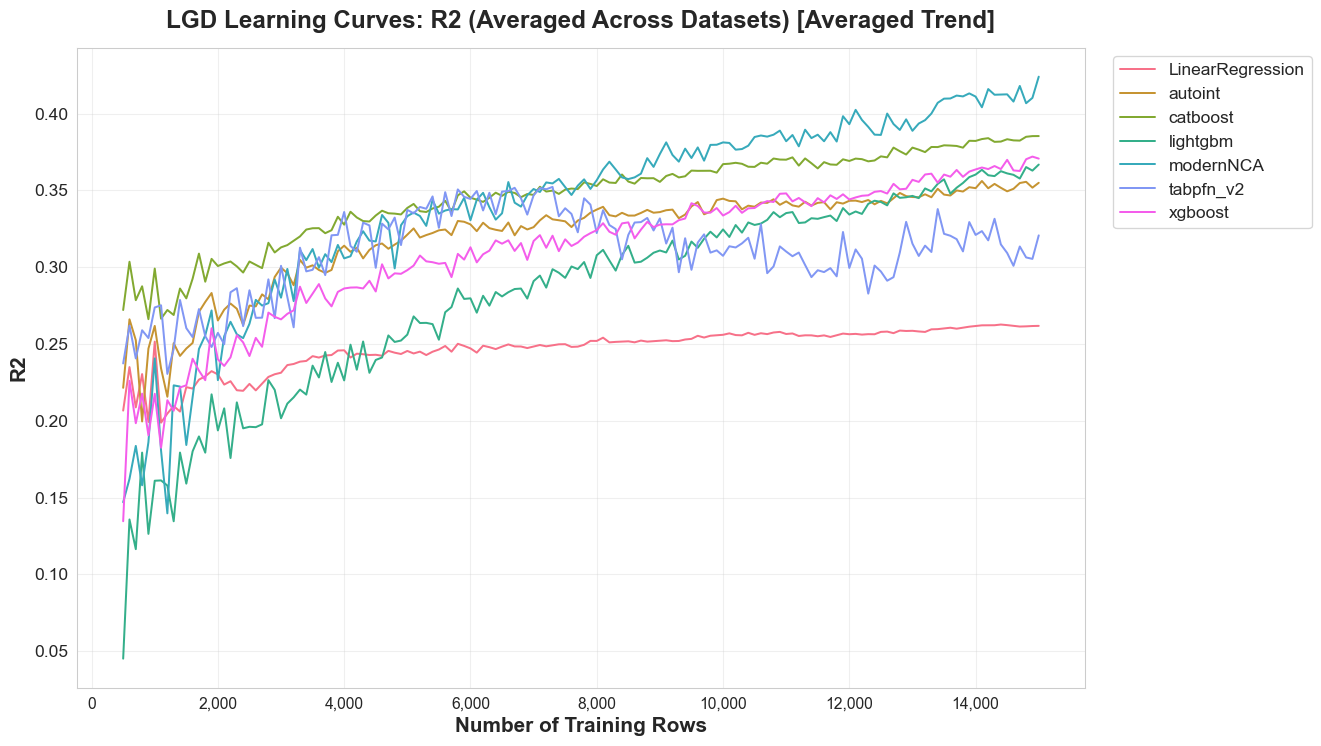


LGD Relative Performance Decay [Averaged Trend]
Saved: lgd_relative_performance_r2_averaged.png


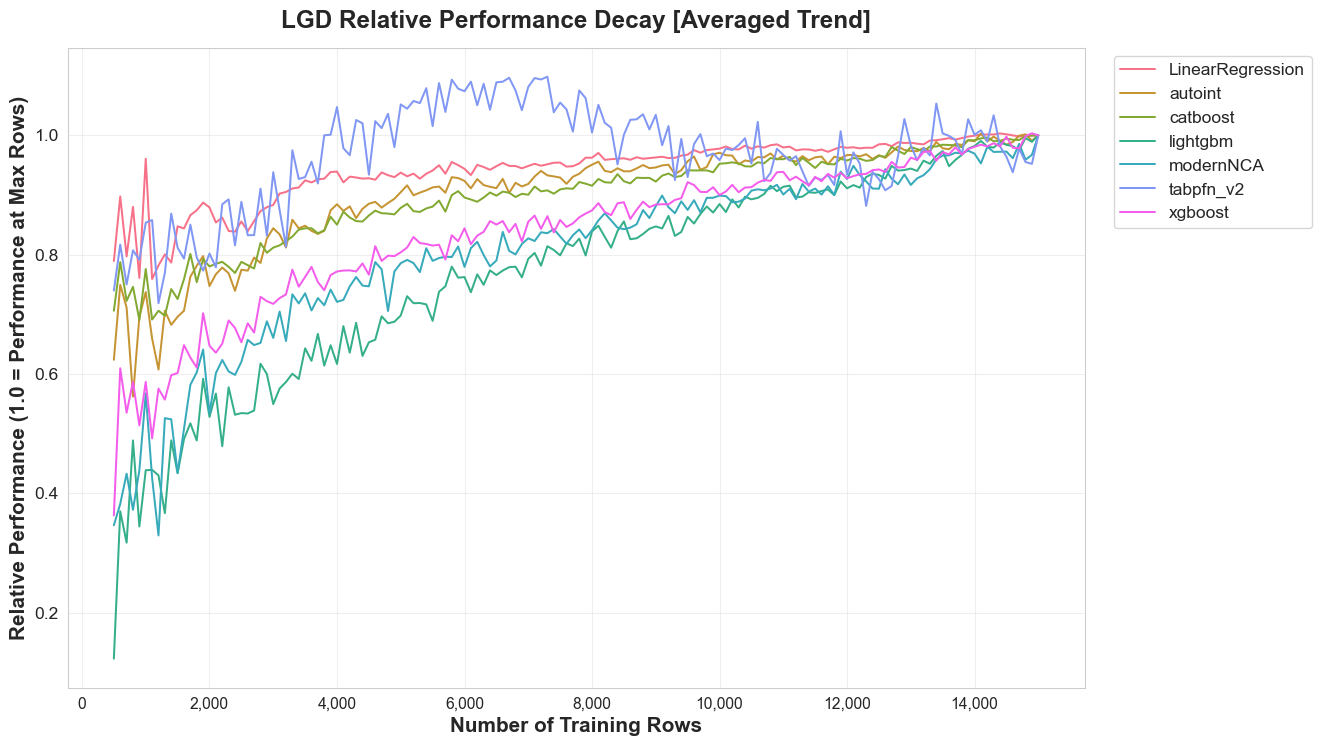


LGD Degradation Analysis
Saved: lgd_degradation_r2.png


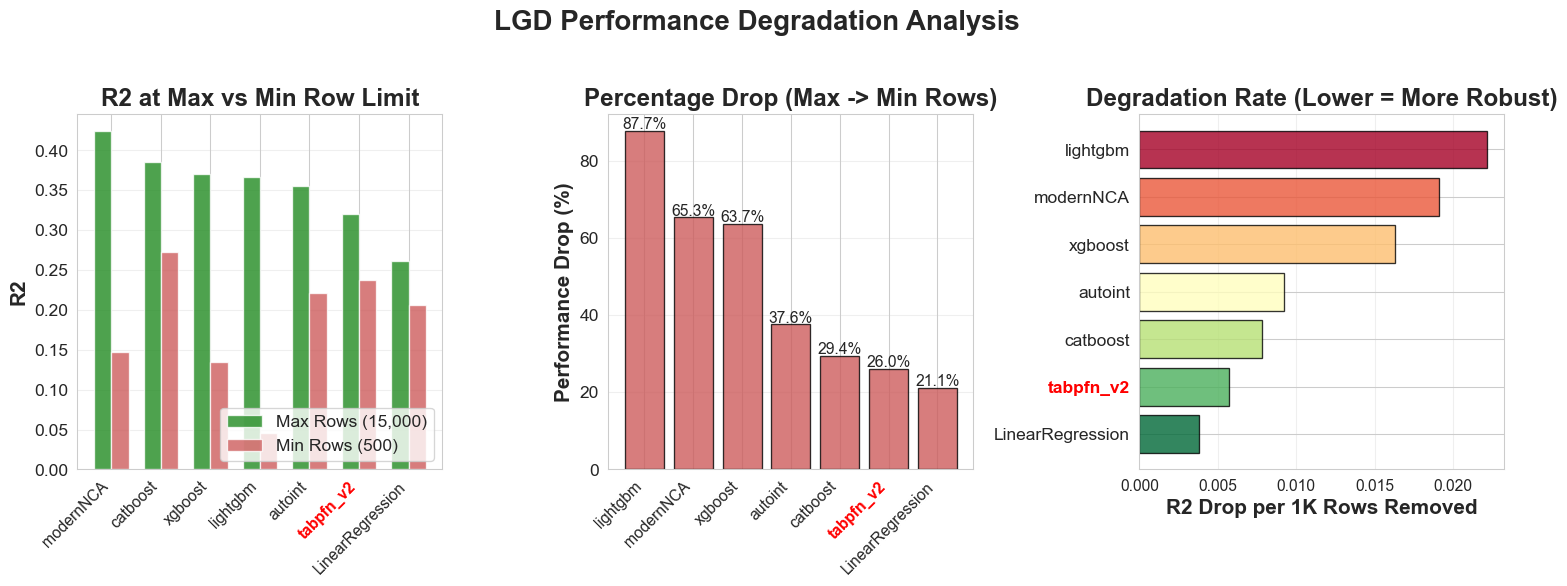

LGD R² Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]
Saved: lgd_tabpfnv2_vs_xgboost_diff.png


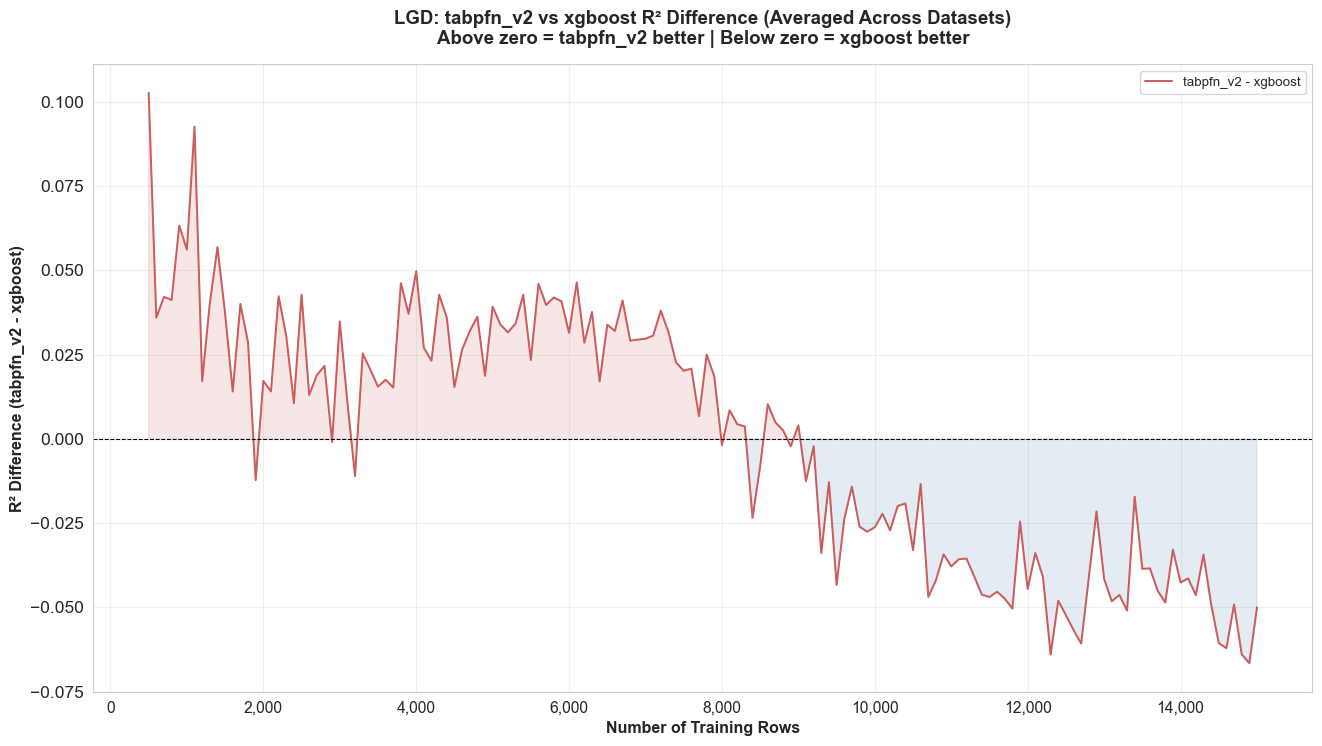

In [17]:
if has_lgd and not lgd_agg.empty:
    # Averaged R2 learning curve (smooth trend)
    print("LGD R2 Learning Curves [Averaged Trend]")
    plot_learning_curves(lgd_agg, 'R2', 'LGD', averaged=True)
    plt.show()
    
    # Averaged Relative Performance Decay
    print("\nLGD Relative Performance Decay [Averaged Trend]")
    plot_relative_performance(lgd_agg, 'R2', 'LGD', averaged=True)
    plt.show()
    
    # Degradation bar charts
    print("\nLGD Degradation Analysis")
    plot_degradation_analysis(lgd_degradation, 'R2', 'LGD')
    plt.show()

    # === tabpfn_v2 vs xgboost R2 difference across row limits ===
    print("LGD R² Difference: tabpfn_v2 - xgboost [Averaged Across Datasets]")
    mean_col = 'R2_mean'
    avg_df = lgd_agg.groupby(['method', 'row_limit'])[mean_col].mean().reset_index()

    tfn = avg_df[avg_df['method'] == 'tabpfn_v2'].sort_values('row_limit').set_index('row_limit')[mean_col]
    xgb = avg_df[avg_df['method'] == 'xgboost'].sort_values('row_limit').set_index('row_limit')[mean_col]

    if not tfn.empty and not xgb.empty:
        common_limits = sorted(set(tfn.index) & set(xgb.index))
        if common_limits:
            # Align differences and convert to numpy for safe fill_between masking
            diff = tfn.loc[common_limits] - xgb.loc[common_limits]
            diff_vals = diff.values
            limits_vals = np.array(common_limits)

            fig, ax = plt.subplots(figsize=(14, 8))
            ax.plot(limits_vals, diff_vals, '-', color='indianred', linewidth=LINE_WIDTH_THICK,
                    label='tabpfn_v2 - xgboost')
            ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
            
            # Use NumPy arrays for the 'where' clause to avoid indexing issues
            ax.fill_between(limits_vals, diff_vals, 0, where=(diff_vals > 0),
                            color='indianred', alpha=0.15, interpolate=True)
            ax.fill_between(limits_vals, diff_vals, 0, where=(diff_vals <= 0),
                            color='steelblue', alpha=0.15, interpolate=True)
            
            ax.set_xlabel('Number of Training Rows', fontsize=12, fontweight='bold')
            ax.set_ylabel('R² Difference (tabpfn_v2 - xgboost)', fontsize=12, fontweight='bold')
            
            # FIXED: Corrected string quoting here
            ax.set_title('LGD: tabpfn_v2 vs xgboost R² Difference (Averaged Across Datasets)\n'
                         'Above zero = tabpfn_v2 better | Below zero = xgboost better',
                         fontsize=14, fontweight='bold', pad=15)
            
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            
            filename = FIGURES_DIR / "lgd_tabpfnv2_vs_xgboost_diff.png"
            plt.savefig(filename, dpi=SAVE_DPI, bbox_inches='tight')
            print(f"Saved: {filename.name}")
            plt.show()
else:
    print("No LGD data available")

### B1.3 Key Methods Comparison (Averaged)

LGD R2 Learning Curves - Key Methods [Averaged Trend]
Saved: lgd_learning_curve_r2_averaged_key.png


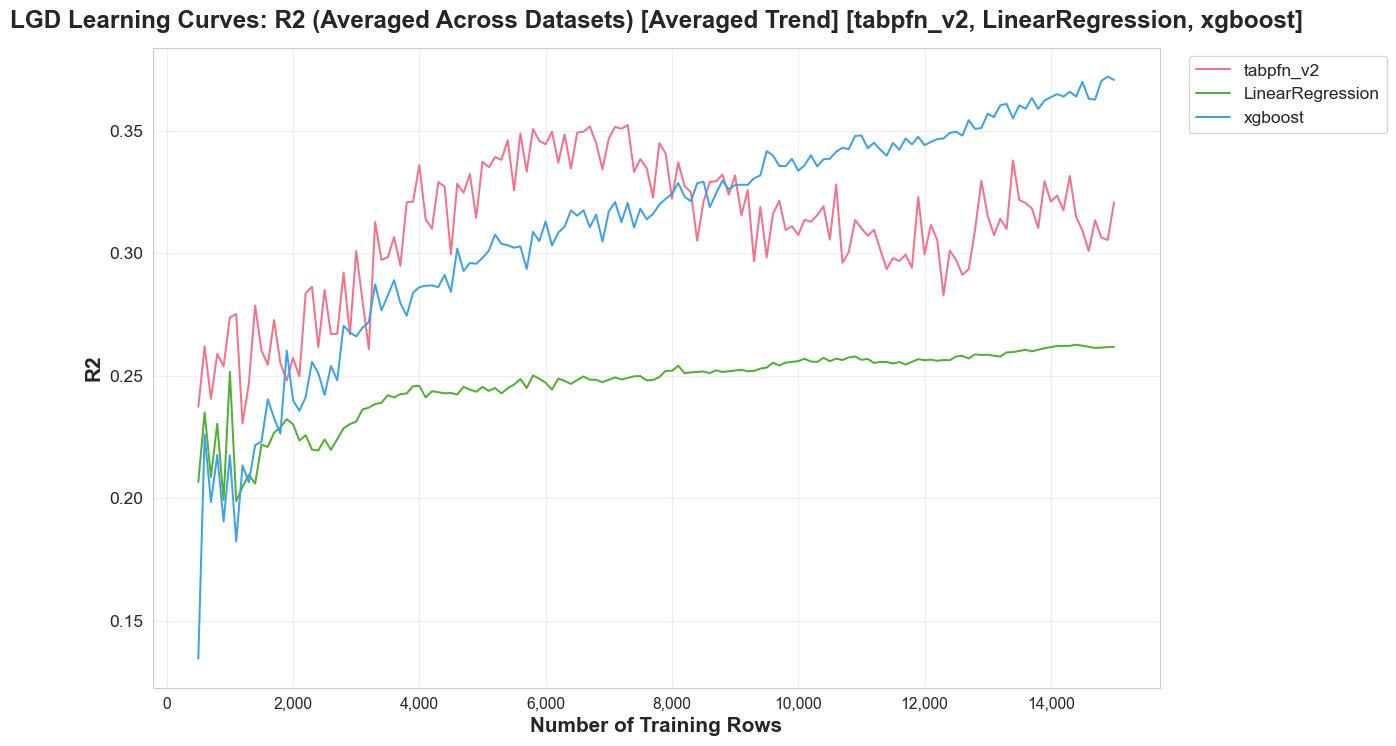


LGD Relative Performance Decay - Key Methods [Averaged Trend]
Saved: lgd_relative_performance_r2_averaged.png


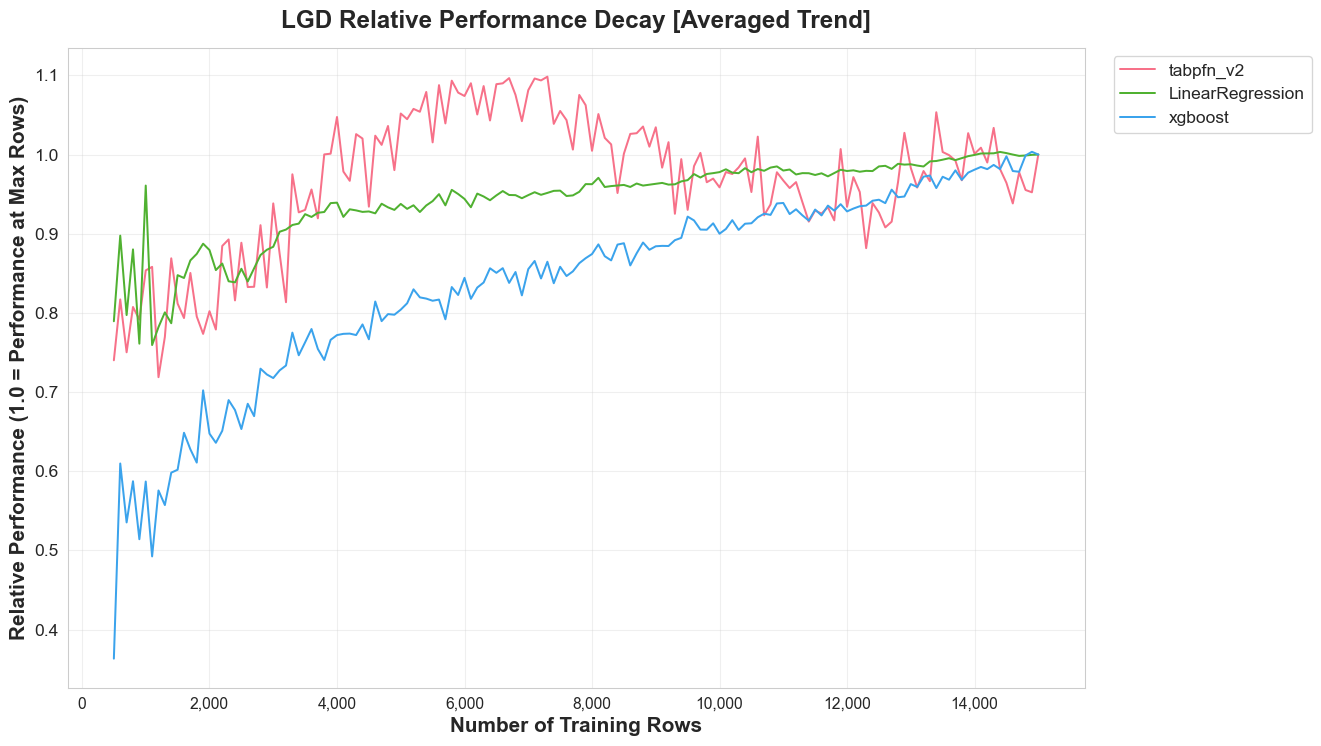

In [18]:
if has_lgd and not lgd_agg.empty:
    # Key methods R2 (averaged)
    print("LGD R2 Learning Curves - Key Methods [Averaged Trend]")
    plot_learning_curves(lgd_agg, 'R2', 'LGD', methods=LGD_KEY_METHODS, averaged=True)
    plt.show()
    
    # Key methods Relative Performance Decay (averaged)
    print("\nLGD Relative Performance Decay - Key Methods [Averaged Trend]")
    plot_relative_performance(lgd_agg, 'R2', 'LGD', methods=LGD_KEY_METHODS, averaged=True)
    plt.show()
else:
    print("No LGD data available")

## B2. Rank Analysis

LGD Rank Evolution [Averaged Trend]
Saved: lgd_rank_evolution_r2_averaged.png


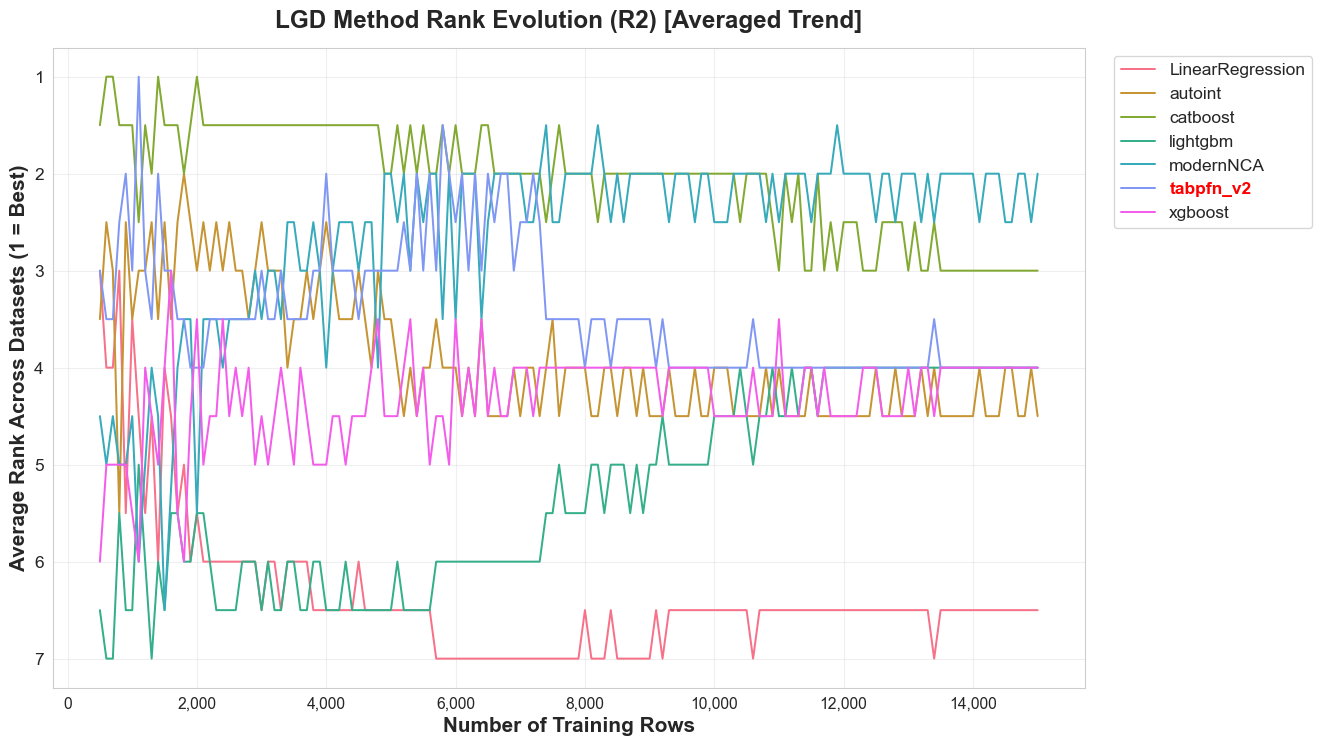


LGD Rank Evolution - Key Methods [Averaged Trend]
Saved: lgd_rank_evolution_r2_averaged_key.png


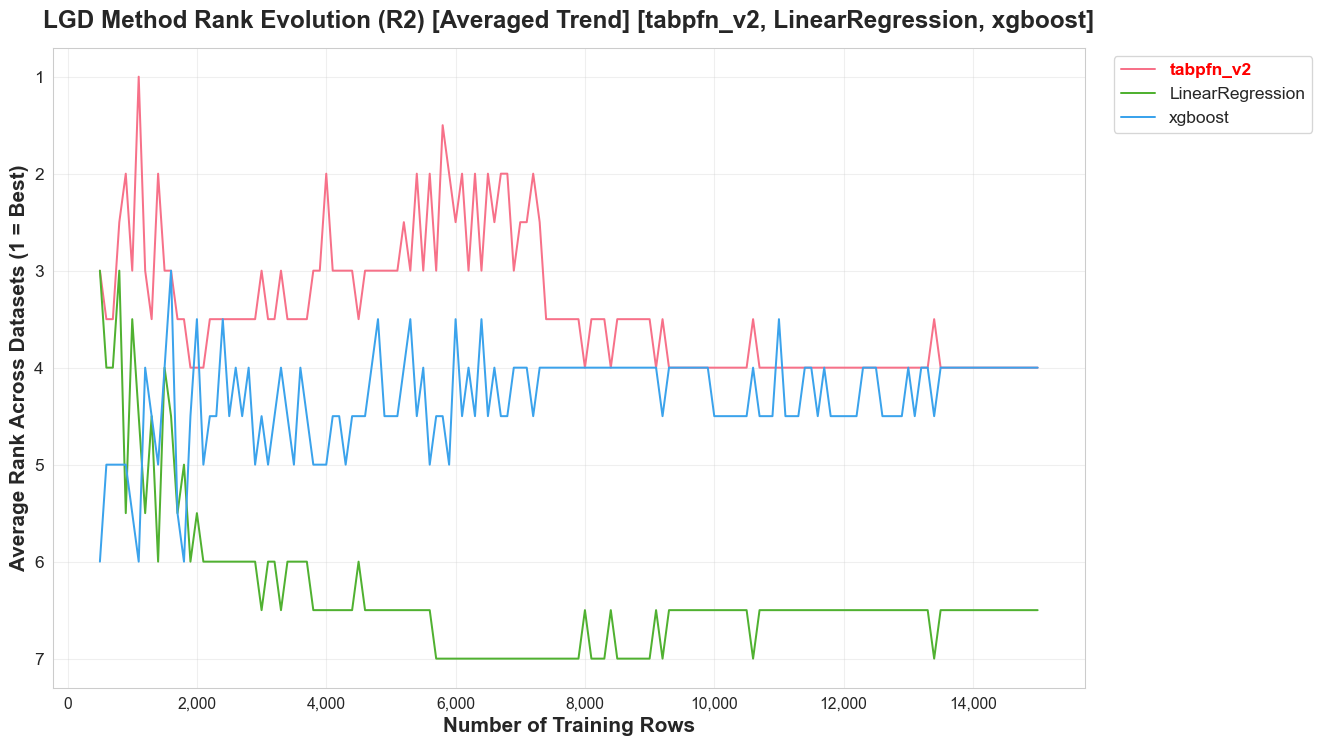


LGD Spearman Rank Correlation
Saved: lgd_spearman_rank_r2.png


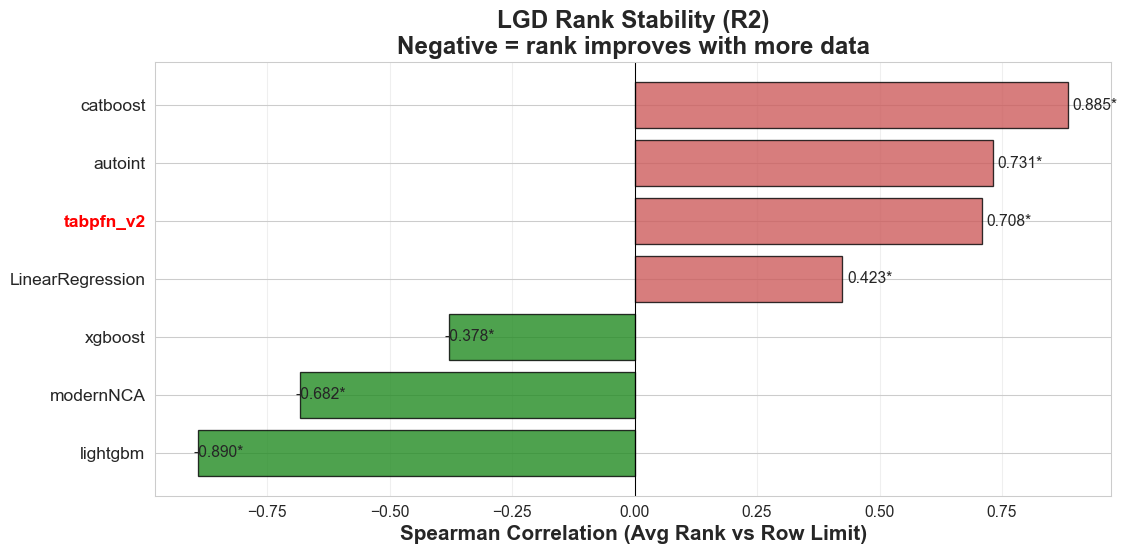


LGD Performance Scaling (Pearson)
Saved: lgd_pearson_metric_r2.png


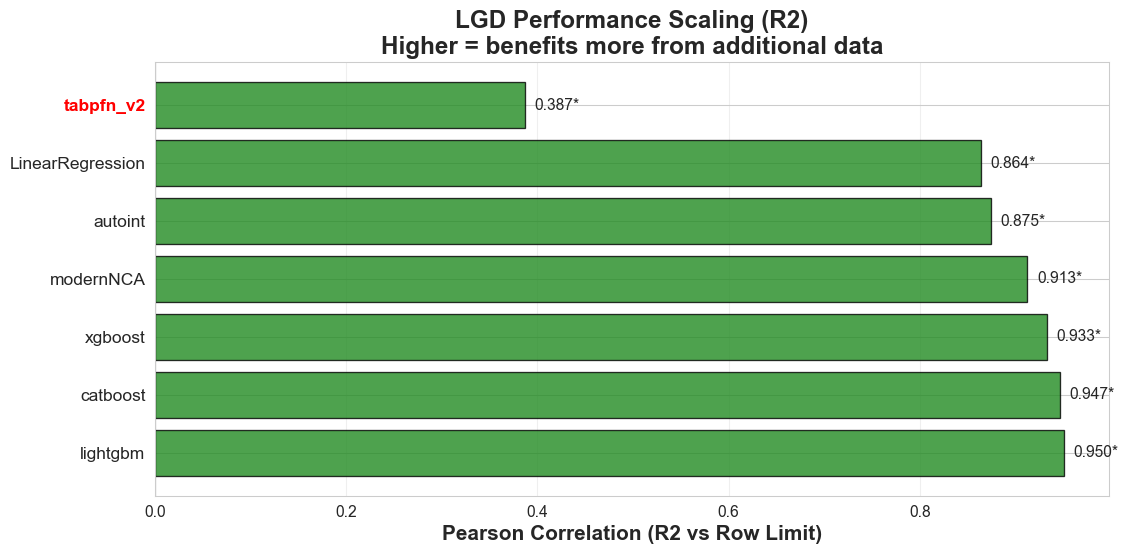

In [19]:
if has_lgd and not lgd_agg.empty:
    # Rank evolution (all methods, averaged trend)
    print("LGD Rank Evolution [Averaged Trend]")
    plot_rank_evolution(lgd_agg, 'R2', 'LGD', averaged=True)
    plt.show()
    
    # Rank evolution - key methods only (averaged trend)
    print("\nLGD Rank Evolution - Key Methods [Averaged Trend]")
    plot_rank_evolution(lgd_agg, 'R2', 'LGD', methods=LGD_KEY_METHODS, averaged=True)
    plt.show()
    
    # Spearman rank correlation
    print("\nLGD Spearman Rank Correlation")
    plot_spearman_rank_correlation(lgd_agg, 'R2', 'LGD')
    plt.show()
    
    # Pearson R2 vs row_limit
    print("\nLGD Performance Scaling (Pearson)")
    plot_metric_vs_rowlimit_correlation(lgd_agg, 'R2', 'LGD')
    plt.show()
else:
    print("No LGD data available")

## B3. Per-Dataset Analysis

Generating per-dataset learning curves for 2 LGD datasets...

Dataset: 0001.heloc
Saved: lgd_learning_curve_r2_0001_heloc_averaged.png


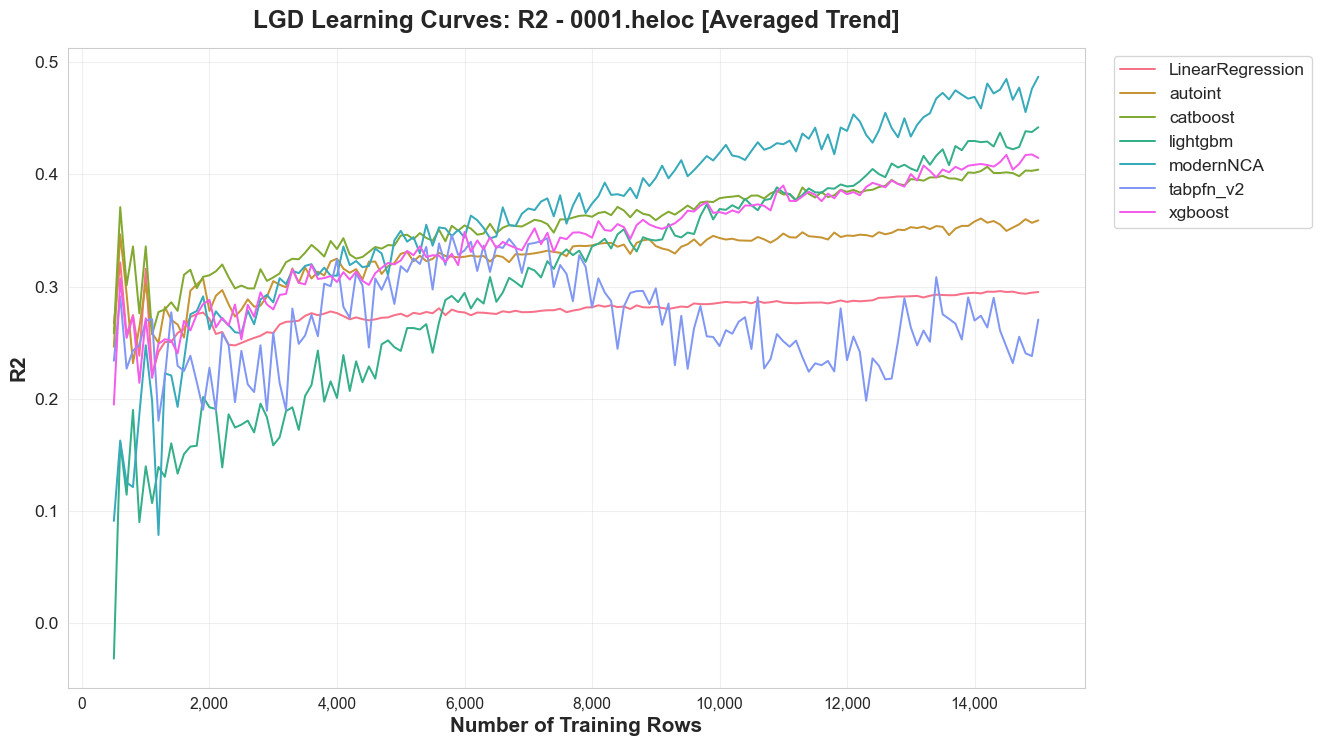

Saved: lgd_learning_curve_r2_0001_heloc_averaged_key.png


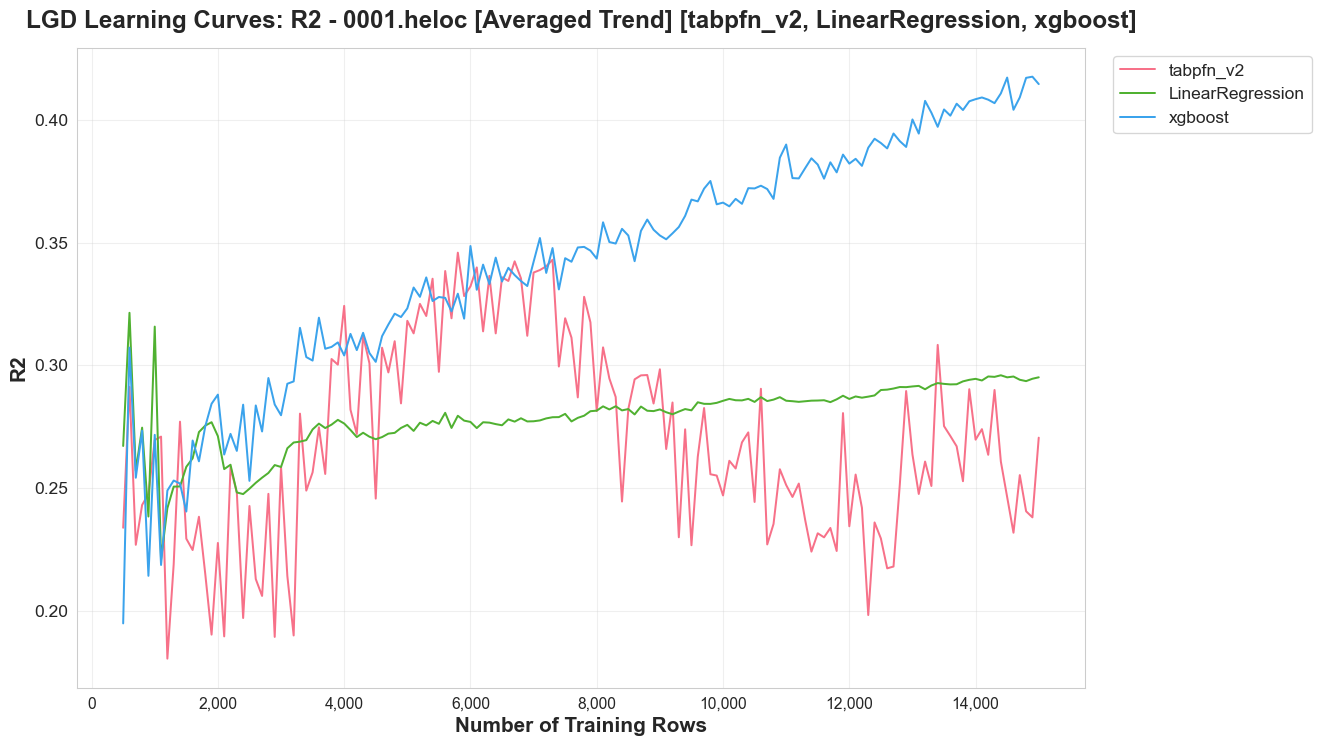

Dataset: 0006.lgd_freddie
Saved: lgd_learning_curve_r2_0006_lgd_freddie_averaged.png


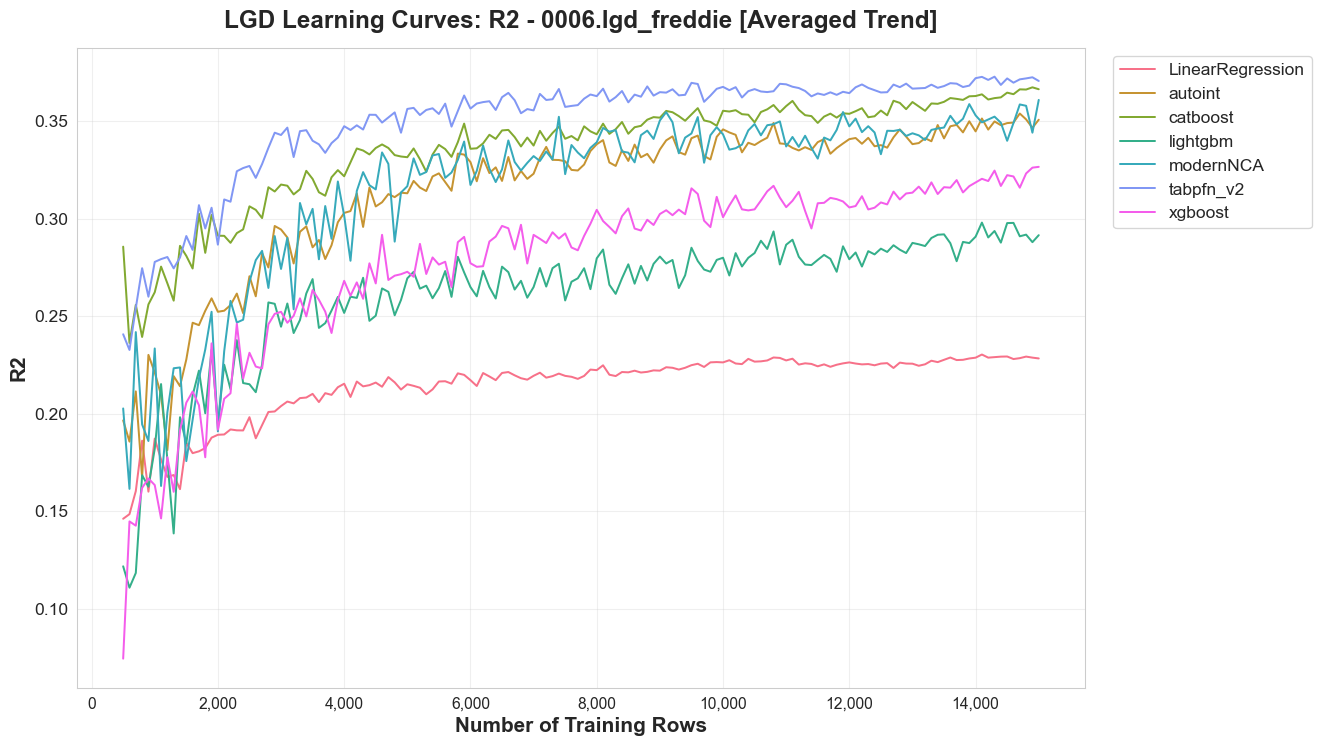

Saved: lgd_learning_curve_r2_0006_lgd_freddie_averaged_key.png


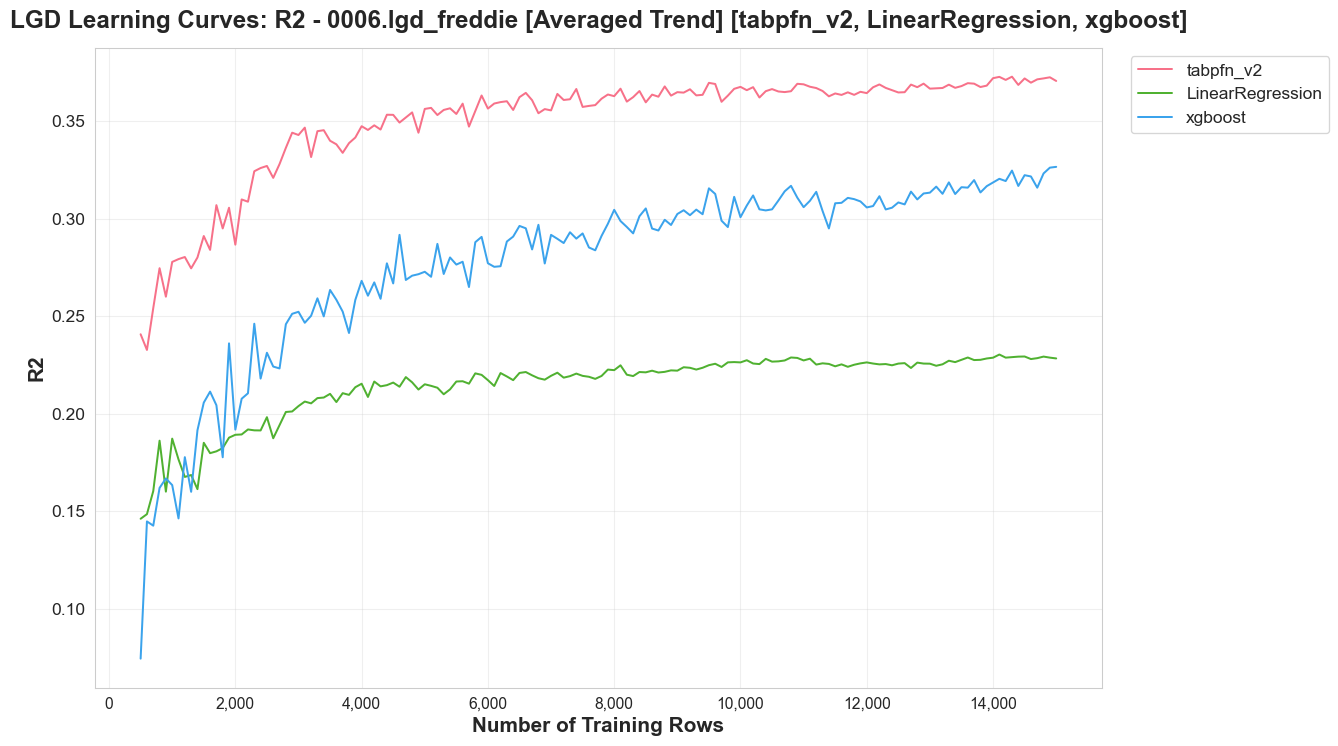

In [20]:
if has_lgd and not lgd_agg.empty:
    datasets = sorted(lgd_agg['dataset'].unique())
    print(f"Generating per-dataset learning curves for {len(datasets)} LGD datasets...\n")
    
    for dataset in datasets:
        print(f"{'='*60}")
        print(f"Dataset: {dataset}")
        print(f"{'='*60}")
        
        # All methods (averaged trend)
        plot_learning_curves(lgd_agg, 'R2', 'LGD', dataset=dataset, averaged=True)
        plt.show()
        
        # Key methods only (averaged trend)
        plot_learning_curves(lgd_agg, 'R2', 'LGD', methods=LGD_KEY_METHODS, dataset=dataset, averaged=True)
        plt.show()
else:
    print("No LGD data available")